In [ ]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install suite2p
!pip install -q rasterio geopandas contextily
!apt install gdal-bin
!pip install fiona
!pip install patchify
!pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.4/661.4 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.5/90.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.3 MB/s eta 0:00:00
  Created wheel for scanimage-tiff-reader: filename=scanimage_tiff_reader-1.4.1.4-cp310-cp310-linux_x86_64.whl size=1092166 sha256=e7e983629a9b233d4acfe73e5a8c0b8352fd6d726d5b1ead98a2725ba97e12ee
  Stored in directory: /root/.cache/pip/wheels/8e/98/62/c1c5cc5e9c031ca500e8e6bb1e38d6e82de28f490f4e73ab94
Successf

In [ ]:

# Import libraries
import sys
sys.path.append('/content/drive/MyDrive/landslide/Codes') # Please put the path accordingly where you have stored the data

import os
import fiona
import numpy as np
import cv2
import rasterio
from rasterio import plot
from rasterio.plot import reshape_as_image
import rasterio.mask
from rasterio.mask import mask
from rasterio.features import rasterize
import pandas as pd
import geopandas as gpd
from osgeo import gdal
from shapely.geometry import box
from shapely.geometry import mapping, Point, Polygon,MultiPolygon
from shapely.ops import unary_union
from glob import glob
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random


In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

In [ ]:
def generate_mask(raster_path, shape_path, output_path, file_name):

    """Function that generates a binary mask from a vector file (shp or geojson)

    raster_path = path to the .tif;

    shape_path = path to the shapefile or GeoJson.

    output_path = Path to save the binary mask.

    file_name = Name of the file.

    """

    #load raster

    with rasterio.open(raster_path, "r") as src:
        raster_img = src.read()
        raster_meta = src.meta

    #load o shapefile ou GeoJson
    train_df = gpd.read_file(shape_path)

    #Verify crs
    if train_df.crs != src.crs:
        print(" Raster crs : {}, Vector crs : {}.\n Convert vector and raster to the same CRS.".format(src.crs,train_df.crs))


    #Function that generates the mask
    def poly_from_utm(polygon, transform):
        poly_pts = []

        poly = unary_union(polygon)
        for i in np.array(poly.exterior.coords):

            poly_pts.append(~transform * tuple(i))

        new_poly = Polygon(poly_pts)
        return new_poly


    poly_shp = []
    im_size = (src.meta['height'], src.meta['width'])
    for num, row in train_df.iterrows():
        if row['geometry'].geom_type == 'Polygon':
            poly = poly_from_utm(row['geometry'], src.meta['transform'])
            poly_shp.append(poly)
        else:
            liste = []
            for polygon in row['geometry'].geoms:
                liste.append(polygon)
                for p in liste:
                  poly = poly_from_utm(p, src.meta['transform'])
                  poly_shp.append(poly)

    mask = rasterize(shapes=poly_shp,
                     out_shape=im_size)

    #Salve
    mask = mask.astype("uint16")

    bin_mask_meta = src.meta.copy()
    bin_mask_meta.update({'count': 1})
    os.chdir(output_path)
    with rasterio.open(file_name, 'w', **bin_mask_meta) as dst:
        dst.write(mask * 255, 1)

In [ ]:
"""
#TO USE IF THE CELL ABOVE DOESNT WORK
def generate_mask(raster_path, shape_path, output_path, file_name):

    Function that generates a binary mask from a vector file (shp or geojson)

    raster_path = path to the .tif;

    shape_path = path to the shapefile or GeoJson.

    output_path = Path to save the binary mask.

    file_name = Name of the file.



    #load raster

    with rasterio.open(raster_path, "r") as src:
        raster_img = src.read()
        raster_meta = src.meta

    #load o shapefile ou GeoJson
    train_df = gpd.read_file(shape_path)

    #Verify crs
    if train_df.crs != src.crs:
        train_df = train_df.to_crs(src.crs)
        print(" Raster crs : {}, Vector crs : {}.\n Convert vector and raster to the same CRS.".format(src.crs,train_df.crs))


    #Function that generates the mask
    def poly_from_utm(polygon, transform):
        poly_pts = []
        poly = unary_union(polygon)
        for coords in np.array(poly.exterior.coords):
            x, y = coords[:2]  # Extract only the first two values (x, y)
            col, row = ~transform * (x, y)
            poly_pts.append((col, row))

        new_poly = Polygon(poly_pts)  # Create a new polygon
        return new_poly


    poly_shp = []
    im_size = (src.meta['height'], src.meta['width'])
    for num, row in train_df.iterrows():
        if row['geometry'].geom_type == 'Polygon':
            poly = poly_from_utm(row['geometry'], src.meta['transform'])
            poly_shp.append(poly)
        else:
            liste = []
            for polygon in row['geometry'].geoms:
                liste.append(polygon)
                for p in liste:
                  poly = poly_from_utm(p, src.meta['transform'])
                  poly_shp.append(poly)

    mask = rasterize(shapes=poly_shp,
                     out_shape=im_size)

    #Salve
    mask = mask.astype("uint16")

    bin_mask_meta = src.meta.copy()
    bin_mask_meta.update({'count': 1})
    os.chdir(output_path)
    with rasterio.open(file_name, 'w', **bin_mask_meta) as dst:
        dst.write(mask * 255, 1)
"""

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Images/Optical/Haiti_post_2.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Inventories/Haiti_2.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Masks"

# Output file name
file_name ="Haiti_2.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Images/Optical/Post/Otis_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Change_Shapes/Otis.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Change_Masks"

# Output file name
file_name ="Otis.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

In [ ]:
def readdata(directory, folder_name):

    data_path = os.path.join(directory, folder_name)
    data_list = {}

    for f in sorted(os.listdir(data_path)):
        fdir = os.path.join(data_path, f)
        _, ext = os.path.splitext(f)
        if ext.lower() == ".tif":
            imgtype = f[-22:-4] # Number of characters of the image file. Example, "Image_1.tif" = 11 characters
            image_data=gdal.Open(fdir)
            bands = [image_data.GetRasterBand(i+1).ReadAsArray() for i in range(image_data.RasterCount)]
            data_list[imgtype] = np.stack(bands, axis=2)

    return data_list

In [ ]:
Data_folder = "/content/drive/MyDrive/landslide/Data/"
image_list1 = readdata(directory=Data_folder, folder_name="Images/Optical/Post")
image_list2 = readdata(directory=Data_folder, folder_name="Images/DEM")
image_list3 = readdata(directory=Data_folder, folder_name="Images/Optical/Pre")
label_list = readdata(directory=Data_folder, folder_name="Masks")
change_list = readdata(directory=Data_folder, folder_name="Change_Masks")

In [ ]:
# Print all the stacks that are collected
print("The collection of images post opt available in the list are:")
print("-"*30)
print(*image_list1, sep='\n')
print("The collection of DEM images available in the list are:")
print("-"*30)
print(*image_list2, sep='\n')
print("The collection of images pre opt available in the list are:")
print("-"*30)
print(*image_list3, sep='\n')
# Print all the stacks that are collected
print("The collection of labels available in the list are:")
print("-"*30)
print(*label_list, sep='\n')
print("The collection of change masks available in the list are:")
print("-"*30)
print(*change_list, sep='\n')

The collection of images post opt available in the list are:
------------------------------
Agatha_post
Burundi_post
Butangbunasi_post
Dominica_post_1
Dominica_post_2
Emilia_post
Haiti_post_1
Haiti_post_2
Honduras_post
India_post
Itogon_post
Japan_post
Kenya_post
Lanao_post
Luding_post
Maerkang_post
Marche_post
Nepal_post
Otis_post
Pacific_NW_post
Palu_post
Papua_post
Rwanda_post
Sanpedro_post
Zeeland_post
Zimbabwe_post
The collection of DEM images available in the list are:
------------------------------
Agatha_DEM
Burundi_DEM
Butangbunasi_DEM
Dominica_DEM_1
Dominica_DEM_2
Emilia_DEM
Haiti_DEM_1
Haiti_DEM_2
Honduras_DEM
India_DEM
Itogon_DEM
Japan_DEM
Kenya_DEM
Lanao_DEM
Luding_DEM
Maerkang_DEM
Marche_DEM
Nepal_DEM
Otis_DEM
Pacific_NW_DEM
Palu_DEM
Papua_DEM
Rwanda_DEM
San_Pedro_DEM
Zeeland_DEM
Zimbabwe_DEM
The collection of images pre opt available in the list are:
------------------------------
Agatha_pre
Burundi_pre
Butangbunasi_pre
Dominica_pre_1
Dominica_pre_2
Emilia_pre
Haiti_pre_

In [ ]:
from patchify import patchify
import tifffile as tiff
import numpy
import tifffile as tiff
from tifffile import imread
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from scipy.spatial import ConvexHull, KDTree
from sklearn.impute import KNNImputer
from scipy.spatial.distance import cdist
from joblib import Parallel, delayed

In [ ]:
import rasterio
import os

# List of raster file paths
raster_files = list(image_list1.keys())
print(raster_files)
# Dictionary to store metadata for each raster
raster_info = {}

for file_path in raster_files:
    print(file_path)
    # Check if file exists before opening
    if os.path.exists(f'/content/drive/MyDrive/landslide/Data/Images/Optical/Post/{file_path}.tif'):
        with rasterio.open(f'/content/drive/MyDrive/landslide/Data/Images/Optical/Post/{file_path}.tif') as src:
            # Store metadata in dictionary
            raster_info[file_path] = {
                "width": src.width,
                "height": src.height,
            }
    else:
        print(f"Warning: File not found: {file_path}")

# Print the dictionary
for raster, info in raster_info.items():
    print(f"Metadata for {raster}:")
    print(info)

['Agatha_post', 'Burundi_post', 'DRC_post', 'Dominica_post_1', 'Dominica_post_2', 'Emilia_post', 'Haiti_post_1', 'Haiti_post_2']
Agatha_post
Burundi_post
DRC_post
Dominica_post_1
Dominica_post_2
Emilia_post
Haiti_post_1
Haiti_post_2
Metadata for Agatha_post:
{'width': 1449, 'height': 2256}
Metadata for Burundi_post:
{'width': 1244, 'height': 1126}
Metadata for DRC_post:
{'width': 1443, 'height': 1408}
Metadata for Dominica_post_1:
{'width': 2732, 'height': 3024}
Metadata for Dominica_post_2:
{'width': 1801, 'height': 2162}
Metadata for Emilia_post:
{'width': 3754, 'height': 2769}
Metadata for Haiti_post_1:
{'width': 5400, 'height': 2862}
Metadata for Haiti_post_2:
{'width': 3964, 'height': 2652}


In [ ]:
import rasterio
import os

# List of raster file paths
raster_files = list(image_list3.keys())
print(raster_files)
# Dictionary to store metadata for each raster
raster_info = {}

for file_path in raster_files:
    print(file_path)
    # Check if file exists before opening
    if os.path.exists(f'/content/drive/MyDrive/landslide/Data/Images/Optical/Pre/{file_path}.tif'):
        with rasterio.open(f'/content/drive/MyDrive/landslide/Data/Images/Optical/Pre/{file_path}.tif') as src:
            # Store metadata in dictionary
            raster_info[file_path] = {
                "width": src.width,
                "height": src.height,
            }
    else:
        print(f"Warning: File not found: {file_path}")

# Print the dictionary
for raster, info in raster_info.items():
    print(f"Metadata for {raster}:")
    print(info)

['Agatha_pre', 'Burundi_pre', 'DRC_pre', 'Dominica_pre_1', 'Dominica_pre_2', 'Emilia_pre', 'Haiti_pre_1', 'Haiti_pre_2']
Agatha_pre
Burundi_pre
DRC_pre
Dominica_pre_1
Dominica_pre_2
Emilia_pre
Haiti_pre_1
Haiti_pre_2
Metadata for Agatha_pre:
{'width': 1449, 'height': 2256}
Metadata for Burundi_pre:
{'width': 1244, 'height': 1126}
Metadata for DRC_pre:
{'width': 1443, 'height': 1408}
Metadata for Dominica_pre_1:
{'width': 2732, 'height': 3024}
Metadata for Dominica_pre_2:
{'width': 1801, 'height': 2162}
Metadata for Emilia_pre:
{'width': 3754, 'height': 2769}
Metadata for Haiti_pre_1:
{'width': 5400, 'height': 2862}
Metadata for Haiti_pre_2:
{'width': 3964, 'height': 2652}


In [ ]:
import rasterio
import os

# List of raster file paths
raster_files = list(image_list2.keys())
print(raster_files)
# Dictionary to store metadata for each raster
raster_info = {}

for file_path in raster_files:
    print(file_path)
    # Check if file exists before opening
    if os.path.exists(f'/content/drive/MyDrive/landslide/Data/Images/DEM/{file_path}.tif'):
        with rasterio.open(f'/content/drive/MyDrive/landslide/Data/Images/DEM/{file_path}.tif') as src:
            # Store metadata in dictionary
            raster_info[file_path] = {
                "width": src.width,
                "height": src.height,
            }
    else:
        print(f"Warning: File not found: {file_path}")

# Print the dictionary
for raster, info in raster_info.items():
    print(f"Metadata for {raster}:")
    print(info)

['Agatha_DEM', 'Burundi_DEM', 'DRC_DEM', 'Dominica_DEM_1', 'Dominica_DEM_2', 'Emilia_DEM', 'Haiti_DEM_1', 'Haiti_DEM_2']
Agatha_DEM
Burundi_DEM
DRC_DEM
Dominica_DEM_1
Dominica_DEM_2
Emilia_DEM
Haiti_DEM_1
Haiti_DEM_2
Metadata for Agatha_DEM:
{'width': 1449, 'height': 2256}
Metadata for Burundi_DEM:
{'width': 1244, 'height': 1126}
Metadata for DRC_DEM:
{'width': 1443, 'height': 1408}
Metadata for Dominica_DEM_1:
{'width': 2732, 'height': 3024}
Metadata for Dominica_DEM_2:
{'width': 1801, 'height': 2163}
Metadata for Emilia_DEM:
{'width': 3754, 'height': 2768}
Metadata for Haiti_DEM_1:
{'width': 3964, 'height': 2652}
Metadata for Haiti_DEM_2:
{'width': 5400, 'height': 2862}


In [ ]:
# Function to patchify an image and return patches as a list
def patchify_image(image, patch_size, step):
    patches = patchify(image, (patch_size, patch_size, image.shape[-1]), step=step)
    patches = patches.reshape(-1, patch_size, patch_size, image.shape[-1])
    return np.array([patch for patch in patches])

# Function to process all ROIs and patchify them into a dictionary
def patchify_roi_dict(image_dict, patch_size, step):
    patched_dict = {}
    for roi_name, image_array in image_dict.items():
        patched_dict[roi_name] = patchify_image(image_array, patch_size, step)
    return patched_dict

# Example patchify process for all image types and masks
PATCHSIZE = 256
STEP = 128

# Image dictionaries (example usage based on your input structure)
image_patches_dict1 = patchify_roi_dict(image_list1, PATCHSIZE, STEP)
image_patches_dict2 = patchify_roi_dict(image_list2, PATCHSIZE, STEP)
image_patches_dict3 = patchify_roi_dict(image_list3, PATCHSIZE, STEP)

# Function for patchifying masks (single channel, normalized)
def patchify_mask(mask, patch_size, step):
    patches = patchify(mask, (patch_size, patch_size, 1), step=step)
    patches = patches.reshape(-1, patch_size, patch_size)
    return np.expand_dims(np.array([patch / 255.0 for patch in patches]), -1)

# Patchify masks and change masks
mask_patches_dict = {}
for roi_name, mask_array in label_list.items():
    mask_patches_dict[roi_name] = patchify_mask(mask_array, PATCHSIZE, STEP)

change_mask_patches_dict = {}
for roi_name, change_mask_array in change_list.items():
    change_mask_patches_dict[roi_name] = patchify_mask(change_mask_array, PATCHSIZE, STEP)

# Example outputs
print("Image Patches 1:", {key: val.shape for key, val in image_patches_dict1.items()})
print("Image Patches 2:", {key: val.shape for key, val in image_patches_dict2.items()})
print("Image Patches 3:", {key: val.shape for key, val in image_patches_dict3.items()})
print("Masks Patches:", {key: val.shape for key, val in mask_patches_dict.items()})
print("Change Masks Patches:", {key: val.shape for key, val in change_mask_patches_dict.items()})

Image Patches 1: {'Agatha_post': (160, 256, 256, 11), 'Burundi_post': (56, 256, 256, 11), 'Butangbunasi_post': (260, 256, 256, 11), 'Dominica_post_1': (440, 256, 256, 11), 'Dominica_post_2': (195, 256, 256, 11), 'Emilia_post': (560, 256, 256, 11), 'Haiti_post_1': (861, 256, 256, 11), 'Haiti_post_2': (551, 256, 256, 11), 'Honduras_post': (72, 256, 256, 11), 'India_post': (840, 256, 256, 11), 'Itogon_post': (391, 256, 256, 11), 'Japan_post': (928, 256, 256, 11), 'Kenya_post': (156, 256, 256, 11), 'Lanao_post': (140, 256, 256, 11), 'Luding_post': (1035, 256, 256, 11), 'Maerkang_post': (812, 256, 256, 11), 'Marche_post': (576, 256, 256, 11), 'Nepal_post': (250, 256, 256, 11), 'Otis_post': (55, 256, 256, 11), 'Pacific_NW_post': (24, 256, 256, 11), 'Palu_post': (180, 256, 256, 11), 'Papua_post': (1320, 256, 256, 11), 'Rwanda_post': (81, 256, 256, 11), 'Sanpedro_post': (800, 256, 256, 11), 'Zeeland_post': (1950, 256, 256, 11), 'Zimbabwe_post': (946, 256, 256, 11)}
Image Patches 2: {'Agatha_DE

In [ ]:
total_patches1 = sum(val.shape[0] for val in image_patches_dict1.values())
total_patches2 = sum(val.shape[0] for val in image_patches_dict2.values())
total_patches3 = sum(val.shape[0] for val in image_patches_dict3.values())

print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)

Total patches in image_list1: 13639
Total patches in image_list2: 13639
Total patches in image_list3: 13639


In [ ]:
del image_list1, image_list2, image_list3, label_list, change_list

In [ ]:
def calculate_landslide_area_ratio_per_patch(mask_dict, patch_size=(256, 256), area_per_patch_km2=6.55):
    """
    Calculates the ratio of landslide area (label=1) to the total image area for each patch in each ROI,
    and then averages the ratios for each ROI.

    Args:
        mask_dict (dict): Dictionary where the keys are ROI names and the values are lists of numpy arrays representing the masks for multiple patches.
        patch_size (tuple): Size of the image patch (height, width).
        area_per_patch_km2 (float): The total area (in km²) covered by one image patch.

    Returns:
        dict: Dictionary with the ROI names as keys and the average landslide area ratio for each ROI.
    """
    landslide_area_ratios = {}

    # Total number of pixels in the patch
    total_pixels = patch_size[0] * patch_size[1]

    # Area per pixel (in km²)
    area_per_pixel_km2 = area_per_patch_km2 / total_pixels

    for roi_name, mask_list in mask_dict.items():
        patch_ratios = []

        # Iterate over all patches in the ROI
        for mask in mask_list:
            # Get the number of landslide pixels (label = 1)
            landslide_pixels = np.sum(mask == 1)

            # Calculate the total area of landslides in km²
            landslide_area_km2 = landslide_pixels * area_per_pixel_km2

            # Calculate the total area of the patch (which is area_per_patch_km2 by definition)
            total_area_km2 = area_per_patch_km2

            # Calculate the ratio of landslide area to total area
            landslide_area_ratio = landslide_area_km2 / total_area_km2

            patch_ratios.append(landslide_area_ratio)

        # Average the ratio for each ROI across all patches
        average_ratio = np.mean(patch_ratios)
        landslide_area_ratios[roi_name] = average_ratio

    return landslide_area_ratios

In [ ]:
# Calculate the landslide area ratio for each patch in each ROI
landslide_area_ratios = calculate_landslide_area_ratio_per_patch(mask_patches_dict)

# Print the results
for roi_name, ratio in landslide_area_ratios.items():
    print(f"Landslide Area Ratio for {roi_name}: {ratio:.4f}")

Landslide Area Ratio for Agatha: 0.0267
Landslide Area Ratio for Burundi: 0.0766
Landslide Area Ratio for Butangbunasi: 0.0096
Landslide Area Ratio for Dominica_1: 0.0155
Landslide Area Ratio for Dominica_2: 0.0292
Landslide Area Ratio for Emilia: 0.0181
Landslide Area Ratio for Haiti_1: 0.0035
Landslide Area Ratio for Haiti_2: 0.0447
Landslide Area Ratio for Honduras: 0.0320
Landslide Area Ratio for India: 0.0007
Landslide Area Ratio for Itogon: 0.0009
Landslide Area Ratio for Japan: 0.0031
Landslide Area Ratio for Kenya: 0.0298
Landslide Area Ratio for Lanao: 0.0006
Landslide Area Ratio for Luding: 0.0097
Landslide Area Ratio for Maerkang: 0.0009
Landslide Area Ratio for Marche: 0.0012
Landslide Area Ratio for Nepal: 0.0033
Landslide Area Ratio for Otis: 0.0292
Landslide Area Ratio for Pacific_NW: 0.0037
Landslide Area Ratio for Palu: 0.0074
Landslide Area Ratio for Papua: 0.0094
Landslide Area Ratio for Rwanda: 0.0042
Landslide Area Ratio for Sanpedro: 0.0031
Landslide Area Ratio fo

In [ ]:
# Replace NoData values with np.nan in all image patches
def replace_nodata_with_nan(image_dict, nodata_value=-9999):

    for roi_name, image_array in image_dict.items():
        # Replace NoData values with np.nan
        updated_images = np.where(image_array == nodata_value, np.nan, image_array)

        # Store the updated images and NaN indices
        image_dict[roi_name] = updated_images

    return image_dict

# Replace NoData values and find NaN indices
image_patches_dict1 = replace_nodata_with_nan(image_patches_dict1, nodata_value=-9999)
image_patches_dict2= replace_nodata_with_nan(image_patches_dict2, nodata_value=-9999)
image_patches_dict3 = replace_nodata_with_nan(image_patches_dict3, nodata_value=-9999)


In [ ]:
# Function to filter out useless image patches from a dictionary
def filter_useless_patches(image_dict,image_dict_1, image_dict_2, mask_dict, change_mask_dict, min_useful_area, max_nodata_proportion):
    filtered_images = {}
    filtered_images_1 = {}
    filtered_images_2 = {}
    filtered_masks = {}
    filtered_changemasks = {}

    # Get ROI names from image_dict and adjust for mask_dict
    image_roi_names = list(image_dict.keys())  # Get ROI names from image_dict
    image_roi_names_1 = list(image_dict_1.keys())  # Get ROI names from image_dict
    image_roi_names_2 = list(image_dict_2.keys())  # Get ROI names from image_dict
    mask_roi_names =  list(mask_dict.keys()) # Adjust for mask_dict

    for image_roi_name, image_roi_name_1, image_roi_name_2, mask_roi_name in zip(image_roi_names,image_roi_names_1, image_roi_names_2, mask_roi_names):  # Iterate over both lists
        # Check if corresponding mask ROI exists before proceeding
        if mask_roi_name in mask_dict:
            image_patches = image_dict[image_roi_name]
            image_patches_1 = image_dict_1[image_roi_name_1]
            image_patches_2 = image_dict_2[image_roi_name_2]
            mask_patches = mask_dict[mask_roi_name]
            change_mask_patches = change_mask_dict[mask_roi_name]

            good_images = []
            good_images_1 = []
            good_images_2 = []
            good_masks = []
            good_changemasks = []

            for img_patch, img_patch_1, img_patch_2, mask_patch, change_mask_patch in zip(image_patches, image_patches_1, image_patches_2, mask_patches, change_mask_patches):
                # Calculate useful area percentage for the mask
                val, counts = np.unique(mask_patch, return_counts=True)
                useful_area = 1 - (counts[0] / counts.sum())

                # Calculate proportion of NoData values in the image patch
                nodata_count = np.isnan(img_patch).sum()
                nodata_proportion = nodata_count / img_patch.size

                # Include the patch if it meets both criteria
                if useful_area >= min_useful_area and nodata_proportion <= max_nodata_proportion:
                    #print(nodata_proportion >= 0.2 )
                    good_images.append(img_patch)
                    good_images_1.append(img_patch_1)
                    good_images_2.append(img_patch_2)
                    good_masks.append(mask_patch)
                    good_changemasks.append(change_mask_patch)

            filtered_images[image_roi_name] = np.array(good_images)
            filtered_images_1[image_roi_name_1] = np.array(good_images_1)
            filtered_images_2[image_roi_name_2] = np.array(good_images_2)
            filtered_masks[mask_roi_name] = np.array(good_masks)
            filtered_changemasks[mask_roi_name] = np.array(good_changemasks)

    return filtered_images, filtered_images_1, filtered_images_2, filtered_masks, filtered_changemasks

# Example patchify process for all image types and masks
MIN_USEFUL_AREA = 0.005  # 0.5%
MAX_NODATA_PROPORTION = 0.1  # 10%

# Filter out useless patches
filtered_images1, filtered_images2, filtered_images3, filtered_masks, filtered_changemasks = filter_useless_patches(
    image_patches_dict1, image_patches_dict2, image_patches_dict3, mask_patches_dict, change_mask_patches_dict, MIN_USEFUL_AREA, MAX_NODATA_PROPORTION
)

# Example outputs
print("Useful Image Patches 1:", {key: val.shape for key, val in filtered_images1.items()})
print("Useful Image Patches 2:", {key: val.shape for key, val in filtered_images2.items()})
print("Useful Image Patches 3:", {key: val.shape for key, val in filtered_images3.items()})
print("Useful Masks Patches:", {key: val.shape for key, val in filtered_masks.items()})
print("Useful Change Masks Patches:", {key: val.shape for key, val in filtered_changemasks.items()})

Useful Image Patches 1: {'Agatha_post': (116, 256, 256, 11), 'Burundi_post': (38, 256, 256, 11), 'Butangbunasi_post': (20, 256, 256, 11), 'Dominica_post_1': (244, 256, 256, 11), 'Dominica_post_2': (74, 256, 256, 11), 'Emilia_post': (302, 256, 256, 11), 'Haiti_post_1': (157, 256, 256, 11), 'Haiti_post_2': (246, 256, 256, 11), 'Honduras_post': (54, 256, 256, 11), 'India_post': (26, 256, 256, 11), 'Itogon_post': (13, 256, 256, 11), 'Japan_post': (170, 256, 256, 11), 'Kenya_post': (101, 256, 256, 11), 'Lanao_post': (6, 256, 256, 11), 'Luding_post': (273, 256, 256, 11), 'Maerkang_post': (41, 256, 256, 11), 'Marche_post': (34, 256, 256, 11), 'Nepal_post': (48, 256, 256, 11), 'Otis_post': (29, 256, 256, 11), 'Pacific_NW_post': (4, 256, 256, 11), 'Palu_post': (45, 256, 256, 11), 'Papua_post': (199, 256, 256, 11), 'Rwanda_post': (22, 256, 256, 11), 'Sanpedro_post': (76, 256, 256, 11), 'Zeeland_post': (636, 256, 256, 11), 'Zimbabwe_post': (77, 256, 256, 11)}
Useful Image Patches 2: {'Agatha_DEM'

In [ ]:
total_patches1 = sum(val.shape[0] for val in filtered_images1.values())
total_patches2 = sum(val.shape[0] for val in filtered_images2.values())
total_patches3 = sum(val.shape[0] for val in filtered_images3.values())

print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)

Total patches in image_list1: 3051
Total patches in image_list2: 3051
Total patches in image_list3: 3051


In [ ]:
del image_patches_dict1, image_patches_dict2, image_patches_dict3, mask_patches_dict, change_mask_patches_dict

In [ ]:
# Calculate the landslide area ratio for each patch in each ROI
landslide_area_ratios = calculate_landslide_area_ratio_per_patch(filtered_masks)

# Print the results
for roi_name, ratio in landslide_area_ratios.items():
    print(f"Landslide Area Ratio for {roi_name}: {ratio:.4f}")

Landslide Area Ratio for Agatha: 0.0362
Landslide Area Ratio for Burundi: 0.1122
Landslide Area Ratio for Butangbunasi: 0.1242
Landslide Area Ratio for Dominica_1: 0.0259
Landslide Area Ratio for Dominica_2: 0.0608
Landslide Area Ratio for Emilia: 0.0320
Landslide Area Ratio for Haiti_1: 0.0150
Landslide Area Ratio for Haiti_2: 0.0936
Landslide Area Ratio for Honduras: 0.0419
Landslide Area Ratio for India: 0.0094
Landslide Area Ratio for Itogon: 0.0079
Landslide Area Ratio for Japan: 0.0117
Landslide Area Ratio for Kenya: 0.0453
Landslide Area Ratio for Lanao: 0.0062
Landslide Area Ratio for Luding: 0.0350
Landslide Area Ratio for Maerkang: 0.0120
Landslide Area Ratio for Marche: 0.0110
Landslide Area Ratio for Nepal: 0.0131
Landslide Area Ratio for Otis: 0.0429
Landslide Area Ratio for Pacific_NW: 0.0204
Landslide Area Ratio for Palu: 0.0276
Landslide Area Ratio for Papua: 0.0575
Landslide Area Ratio for Rwanda: 0.0137
Landslide Area Ratio for Sanpedro: 0.0273
Landslide Area Ratio fo

In [ ]:
def remove_channels(image_dict, num_channels_to_remove):
    updated_dict = {}
    for roi_name, image_patches in image_dict.items():
        updated_patches = [patch[:, :, :num_channels_to_remove] for patch in image_patches]
        updated_dict[roi_name] = np.array(updated_patches)
    return updated_dict

filtered_images1 = remove_channels(filtered_images1 , 6)
filtered_images3 = remove_channels(filtered_images3 , 6)
print("Useful Image Patches 1:", {key: val.shape for key, val in filtered_images1.items()})
print("Useful Image Patches 3:", {key: val.shape for key, val in filtered_images3.items()})

Useful Image Patches 1: {'Agatha_post': (116, 256, 256, 6), 'Burundi_post': (38, 256, 256, 6), 'Butangbunasi_post': (20, 256, 256, 6), 'Dominica_post_1': (244, 256, 256, 6), 'Dominica_post_2': (74, 256, 256, 6), 'Emilia_post': (302, 256, 256, 6), 'Haiti_post_1': (157, 256, 256, 6), 'Haiti_post_2': (246, 256, 256, 6), 'Honduras_post': (54, 256, 256, 6), 'India_post': (26, 256, 256, 6), 'Itogon_post': (13, 256, 256, 6), 'Japan_post': (170, 256, 256, 6), 'Kenya_post': (101, 256, 256, 6), 'Lanao_post': (6, 256, 256, 6), 'Luding_post': (273, 256, 256, 6), 'Maerkang_post': (41, 256, 256, 6), 'Marche_post': (34, 256, 256, 6), 'Nepal_post': (48, 256, 256, 6), 'Otis_post': (29, 256, 256, 6), 'Pacific_NW_post': (4, 256, 256, 6), 'Palu_post': (45, 256, 256, 6), 'Papua_post': (199, 256, 256, 6), 'Rwanda_post': (22, 256, 256, 6), 'Sanpedro_post': (76, 256, 256, 6), 'Zeeland_post': (636, 256, 256, 6), 'Zimbabwe_post': (77, 256, 256, 6)}
Useful Image Patches 3: {'Agatha_pre': (116, 256, 256, 6), 'Bur

In [ ]:
#Preprocess DEM data
def process_roi_patches(roi_dict):

    updated_roi_dict = {}

    for roi_name, image_stack in roi_dict.items():
        #print(f"Processing ROI: {roi_name}")

        updated_stack = []
        for patch in image_stack:
            # Extract individual bands
            band_3 = patch[:, :, 2]  # 3rd band

            # Compute sin(3rd band) and cos(3rd band)
            sin_band = np.sin(band_3)
            cos_band = np.cos(band_3)

            # Replace the 3rd band with sin and cos bands
            # Add new dimensions for stacking
            sin_band = np.expand_dims(sin_band, axis=-1)
            cos_band = np.expand_dims(cos_band, axis=-1)

            # Remove the 3rd band and insert new bands
            modified_patch = np.concatenate((
                patch[:, :, :2],  # Keep bands 1 and 2
                sin_band,         # Insert sin(3rd band)
                cos_band,         # Insert cos(3rd band)
                patch[:, :, 3:]   # Keep remaining bands from 4 onward
            ), axis=-1)

            updated_stack.append(modified_patch)

        # Update the dictionary with the modified stack
        updated_roi_dict[roi_name] = np.array(updated_stack)

    return updated_roi_dict

# Process all ROIs
filtered_images2 = process_roi_patches(filtered_images2)
print("Useful Image Patches 2:", {key: val.shape for key, val in filtered_images2.items()})

Useful Image Patches 2: {'Agatha_DEM': (116, 256, 256, 6), 'Burundi_DEM': (38, 256, 256, 6), 'Butangbunasi_DEM': (20, 256, 256, 6), 'Dominica_DEM_1': (244, 256, 256, 6), 'Dominica_DEM_2': (74, 256, 256, 6), 'Emilia_DEM': (302, 256, 256, 6), 'Haiti_DEM_1': (157, 256, 256, 6), 'Haiti_DEM_2': (246, 256, 256, 6), 'Honduras_DEM': (54, 256, 256, 6), 'India_DEM': (26, 256, 256, 6), 'Itogon_DEM': (13, 256, 256, 6), 'Japan_DEM': (170, 256, 256, 6), 'Kenya_DEM': (101, 256, 256, 6), 'Lanao_DEM': (6, 256, 256, 6), 'Luding_DEM': (273, 256, 256, 6), 'Maerkang_DEM': (41, 256, 256, 6), 'Marche_DEM': (34, 256, 256, 6), 'Nepal_DEM': (48, 256, 256, 6), 'Otis_DEM': (29, 256, 256, 6), 'Pacific_NW_DEM': (4, 256, 256, 6), 'Palu_DEM': (45, 256, 256, 6), 'Papua_DEM': (199, 256, 256, 6), 'Rwanda_DEM': (22, 256, 256, 6), 'Sanpedro_DEM': (76, 256, 256, 6), 'Zeeland_DEM': (636, 256, 256, 6), 'Zimbabwe_DEM': (77, 256, 256, 6)}


/usr/local/lib/python3.10/dist-packages/matplotlib/cm.py:489: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


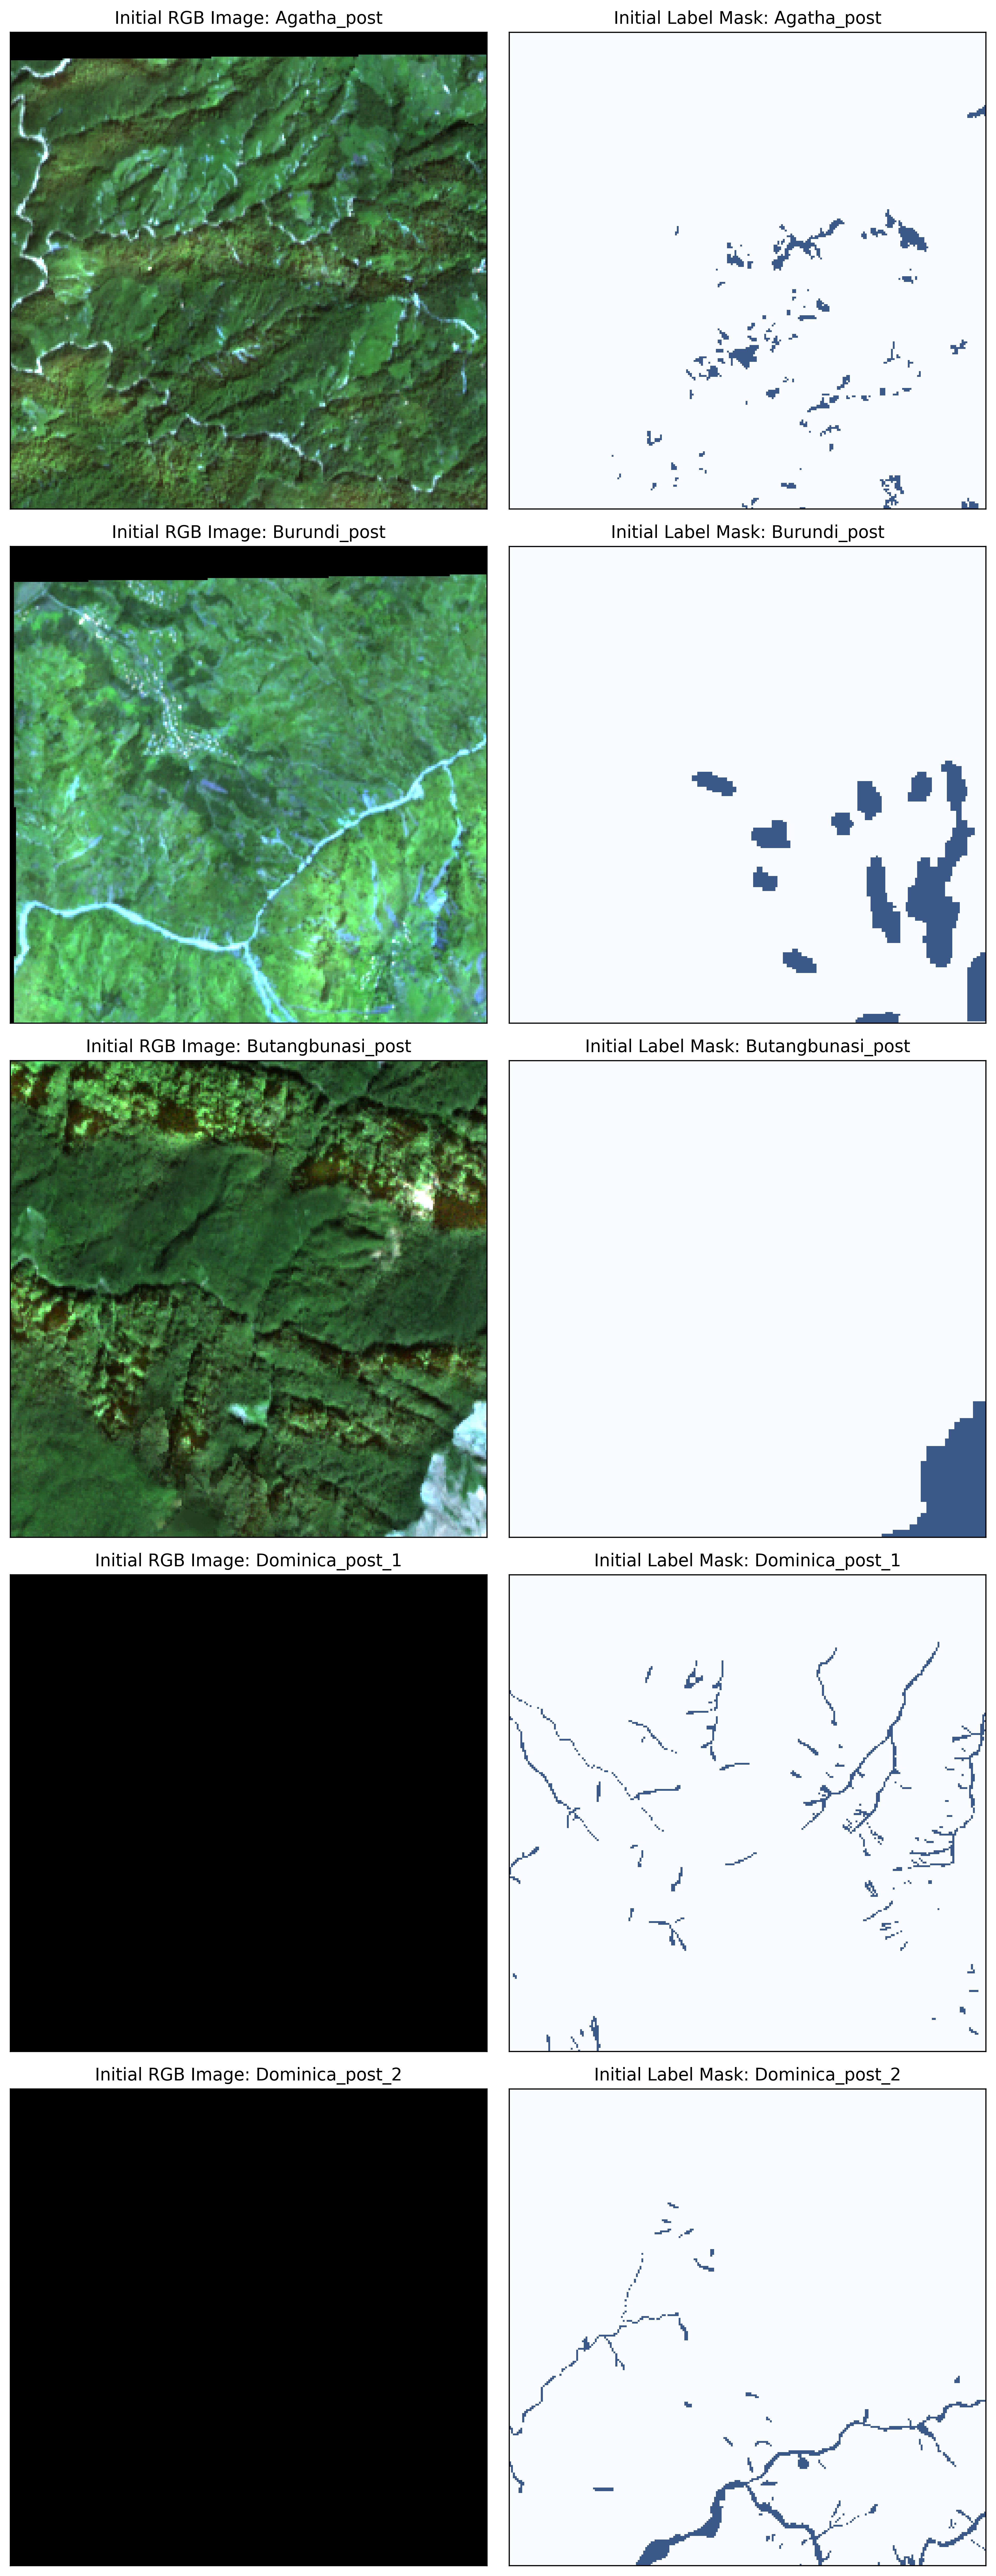

In [ ]:
# Plot the first image patch of five ROIs
roi_names_to_plot = list(filtered_images1.keys())[:5]
roi_names1_to_plot = list(filtered_masks.keys())[:5]

fig, axarr = plt.subplots(len(roi_names_to_plot), 2, figsize=(10, len(roi_names_to_plot) * 5))
for i, (roi_name, roi_name1) in enumerate(zip(roi_names_to_plot, roi_names1_to_plot)):
    workimage_1 = filtered_images1[roi_name]
    workmask = filtered_masks[roi_name1]

    axarr[i, 0].imshow(workimage_1[0][:, :, :3]/1000)  # Display the first three channels as RGB
    axarr[i, 0].set_title(f"Initial RGB Image: {roi_name}")
    axarr[i, 0].set(xticks=[], yticks=[])

    axarr[i, 1].imshow(np.squeeze(workmask[0]), cmap='Blues', alpha=0.8)
    axarr[i, 1].set_title(f"Initial Label Mask: {roi_name}")
    axarr[i, 1].set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [ ]:
#Normalize the values between -1 and 1
def normalize_patches(roi_dict, exclude_indices, nodata_value=np.nan):

    def normalize_channels(data, channels_to_normalize, nodata_value):

        normalized_data = data.copy()

        for i in range(len(normalized_data)):  # Iterate over patches
            for j in channels_to_normalize:  # Iterate over channels to normalize
                # Get the channel data
                channel_data = normalized_data[i, :, :, j]

                # Create a mask for valid data (not NoData)
                valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)

                # Normalize only valid data
                if np.any(valid_mask):  # Proceed if there are valid values
                    min_val = channel_data[valid_mask].min()
                    max_val = channel_data[valid_mask].max()
                    range_val = max_val - min_val

                    # Avoid division by zero
                    if range_val != 0:
                        channel_data[valid_mask] = ((channel_data[valid_mask] - min_val) / range_val)* 2 - 1
                    else:
                        channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

                # Assign the normalized channel data back
                normalized_data[i, :, :, j] = channel_data

        return normalized_data

    # Process each ROI in the dictionary
    normalized_roi_dict = {}
    for roi_name, image_stack in roi_dict.items():
        #print(f"Normalizing patches for ROI: {roi_name}")

        total_channels = image_stack.shape[-1]  # Get the number of channels
        channels_to_normalize = [i for i in range(total_channels) if i not in exclude_indices]

        # Normalize the stack
        normalized_stack = normalize_channels(image_stack, channels_to_normalize, nodata_value)
        normalized_roi_dict[roi_name] = normalized_stack

    return normalized_roi_dict

exclude_indices = [2,3]  # Indices of channels to exclude
nodata_value = np.nan  # Specify the NoData value if applicable

# Normalize the patches for each ROI
filtered_images2 = normalize_patches(filtered_images2, exclude_indices, nodata_value)

# Verify normalization
for roi_name, patches in filtered_images2.items():
    print(f"{roi_name}: Min = {np.nanmin(patches)}, Max = {np.nanmax(patches)}")


Agatha_DEM: Min = -1.0, Max = 1.0
Burundi_DEM: Min = -1.0, Max = 1.0
Butangbunasi_DEM: Min = -1.0, Max = 1.0
Dominica_DEM_1: Min = -1.0, Max = 1.0
Dominica_DEM_2: Min = -1.0, Max = 1.0
Emilia_DEM: Min = -1.0, Max = 1.0
Haiti_DEM_1: Min = -1.0, Max = 1.0
Haiti_DEM_2: Min = -1.0, Max = 1.0
Honduras_DEM: Min = -1.0, Max = 1.0
India_DEM: Min = -1.0, Max = 1.0
Itogon_DEM: Min = -1.0, Max = 1.0
Japan_DEM: Min = -1.0, Max = 1.0
Kenya_DEM: Min = -1.0, Max = 1.0
Lanao_DEM: Min = -1.0, Max = 1.0
Luding_DEM: Min = -1.0, Max = 1.0
Maerkang_DEM: Min = -1.0, Max = 1.0
Marche_DEM: Min = -1.0, Max = 1.0
Nepal_DEM: Min = -1.0, Max = 1.0
Otis_DEM: Min = -1.0, Max = 1.0
Pacific_NW_DEM: Min = -1.0, Max = 1.0
Palu_DEM: Min = -1.0, Max = 1.0
Papua_DEM: Min = -1.0, Max = 1.0
Rwanda_DEM: Min = -1.0, Max = 1.0
Sanpedro_DEM: Min = -1.0, Max = 1.0
Zeeland_DEM: Min = -1.0, Max = 1.0
Zimbabwe_DEM: Min = -1.0, Max = 1.0


In [ ]:
#For optical images
exclude_indices = []  # Indices of channels to exclude
nodata_value = np.nan  # Specify the NoData value if applicable

# Normalize the patches for each ROI
filtered_images1 = normalize_patches(filtered_images1, exclude_indices, nodata_value)
filtered_images3 = normalize_patches(filtered_images3, exclude_indices, nodata_value)


# Verify normalization
for roi_name, patches in filtered_images1.items():
    print(f"{roi_name}: Min = {np.nanmin(patches)}, Max = {np.nanmax(patches)}")

Agatha_post: Min = -1.0, Max = 1.0
Burundi_post: Min = -1.0, Max = 1.0
Butangbunasi_post: Min = -1.0, Max = 1.0
Dominica_post_1: Min = -1.0, Max = 1.0
Dominica_post_2: Min = -1.0, Max = 1.0
Emilia_post: Min = -1.0, Max = 1.0
Haiti_post_1: Min = -1.0, Max = 1.0
Haiti_post_2: Min = -1.0, Max = 1.0
Honduras_post: Min = -1.0, Max = 1.0
India_post: Min = -1.0, Max = 1.0
Itogon_post: Min = -1.0, Max = 1.0
Japan_post: Min = -1.0, Max = 1.0
Kenya_post: Min = -1.0, Max = 1.0
Lanao_post: Min = -1.0, Max = 1.0
Luding_post: Min = -1.0, Max = 1.0
Maerkang_post: Min = -1.0, Max = 1.0
Marche_post: Min = -1.0, Max = 1.0
Nepal_post: Min = -1.0, Max = 1.0
Otis_post: Min = -1.0, Max = 1.0
Pacific_NW_post: Min = -1.0, Max = 1.0
Palu_post: Min = -1.0, Max = 1.0
Papua_post: Min = -1.0, Max = 1.0
Rwanda_post: Min = -1.0, Max = 1.0
Sanpedro_post: Min = -1.0, Max = 1.0
Zeeland_post: Min = -1.0, Max = 1.0
Zimbabwe_post: Min = -1.0, Max = 1.0


In [ ]:
def count_values_in_patches(useful_masks_patches):

    result = {}

    # Iterate through each region and count occurrences of 0 and 1
    for region, mask_array in useful_masks_patches.items():
        unique, counts = np.unique(mask_array, return_counts=True)
        count_dict = dict(zip(unique, counts))

        # Check for 0  and their counts
        count_0 = count_dict.get(0, 0)  # Default to 0 if 0 is not found
        total_pixels = mask_array.size

        # Calculate percentage of 0s
        percentage_0 = (count_0 / total_pixels) * 100 if total_pixels > 0 else 0

        result[region] = {'0_percentage': percentage_0}

    return result

In [ ]:
result = count_values_in_patches(filtered_images1)
for region, counts in result.items():
    print(f"Region: {region},  0 percentage: {counts['0_percentage']:.2f}%")

Region: Agatha_post,  0 percentage: 0.00%
Region: Burundi_post,  0 percentage: 0.00%
Region: Butangbunasi_post,  0 percentage: 0.00%
Region: Dominica_post_1,  0 percentage: 0.00%
Region: Dominica_post_2,  0 percentage: 0.00%
Region: Emilia_post,  0 percentage: 0.00%
Region: Haiti_post_1,  0 percentage: 0.00%
Region: Haiti_post_2,  0 percentage: 0.00%
Region: Honduras_post,  0 percentage: 0.00%
Region: India_post,  0 percentage: 0.00%
Region: Itogon_post,  0 percentage: 0.00%
Region: Japan_post,  0 percentage: 0.00%
Region: Kenya_post,  0 percentage: 0.01%
Region: Lanao_post,  0 percentage: 0.00%
Region: Luding_post,  0 percentage: 0.00%
Region: Maerkang_post,  0 percentage: 0.00%
Region: Marche_post,  0 percentage: 0.00%
Region: Nepal_post,  0 percentage: 0.00%
Region: Otis_post,  0 percentage: 0.00%
Region: Pacific_NW_post,  0 percentage: 0.02%
Region: Palu_post,  0 percentage: 0.00%
Region: Papua_post,  0 percentage: 0.00%
Region: Rwanda_post,  0 percentage: 0.00%
Region: Sanpedro_po

In [ ]:
result = count_values_in_patches(filtered_images2)
for region, counts in result.items():
    print(f"Region: {region},  0 percentage: {counts['0_percentage']:.2f}%")

Region: Agatha_DEM,  0 percentage: 0.23%
Region: Burundi_DEM,  0 percentage: 0.24%
Region: Butangbunasi_DEM,  0 percentage: 0.16%
Region: Dominica_DEM_1,  0 percentage: 0.77%
Region: Dominica_DEM_2,  0 percentage: 1.29%
Region: Emilia_DEM,  0 percentage: 0.29%
Region: Haiti_DEM_1,  0 percentage: 0.28%
Region: Haiti_DEM_2,  0 percentage: 0.28%
Region: Honduras_DEM,  0 percentage: 0.35%
Region: India_DEM,  0 percentage: 0.25%
Region: Itogon_DEM,  0 percentage: 0.18%
Region: Japan_DEM,  0 percentage: 0.33%
Region: Kenya_DEM,  0 percentage: 0.11%
Region: Lanao_DEM,  0 percentage: 0.48%
Region: Luding_DEM,  0 percentage: 0.35%
Region: Maerkang_DEM,  0 percentage: 0.17%
Region: Marche_DEM,  0 percentage: 0.25%
Region: Nepal_DEM,  0 percentage: 0.21%
Region: Otis_DEM,  0 percentage: 0.32%
Region: Pacific_NW_DEM,  0 percentage: 0.67%
Region: Palu_DEM,  0 percentage: 0.33%
Region: Papua_DEM,  0 percentage: 0.21%
Region: Rwanda_DEM,  0 percentage: 0.28%
Region: San_Pedro_DEM,  0 percentage: 0.25

Boundary NoData detected for ROI: Agatha_post


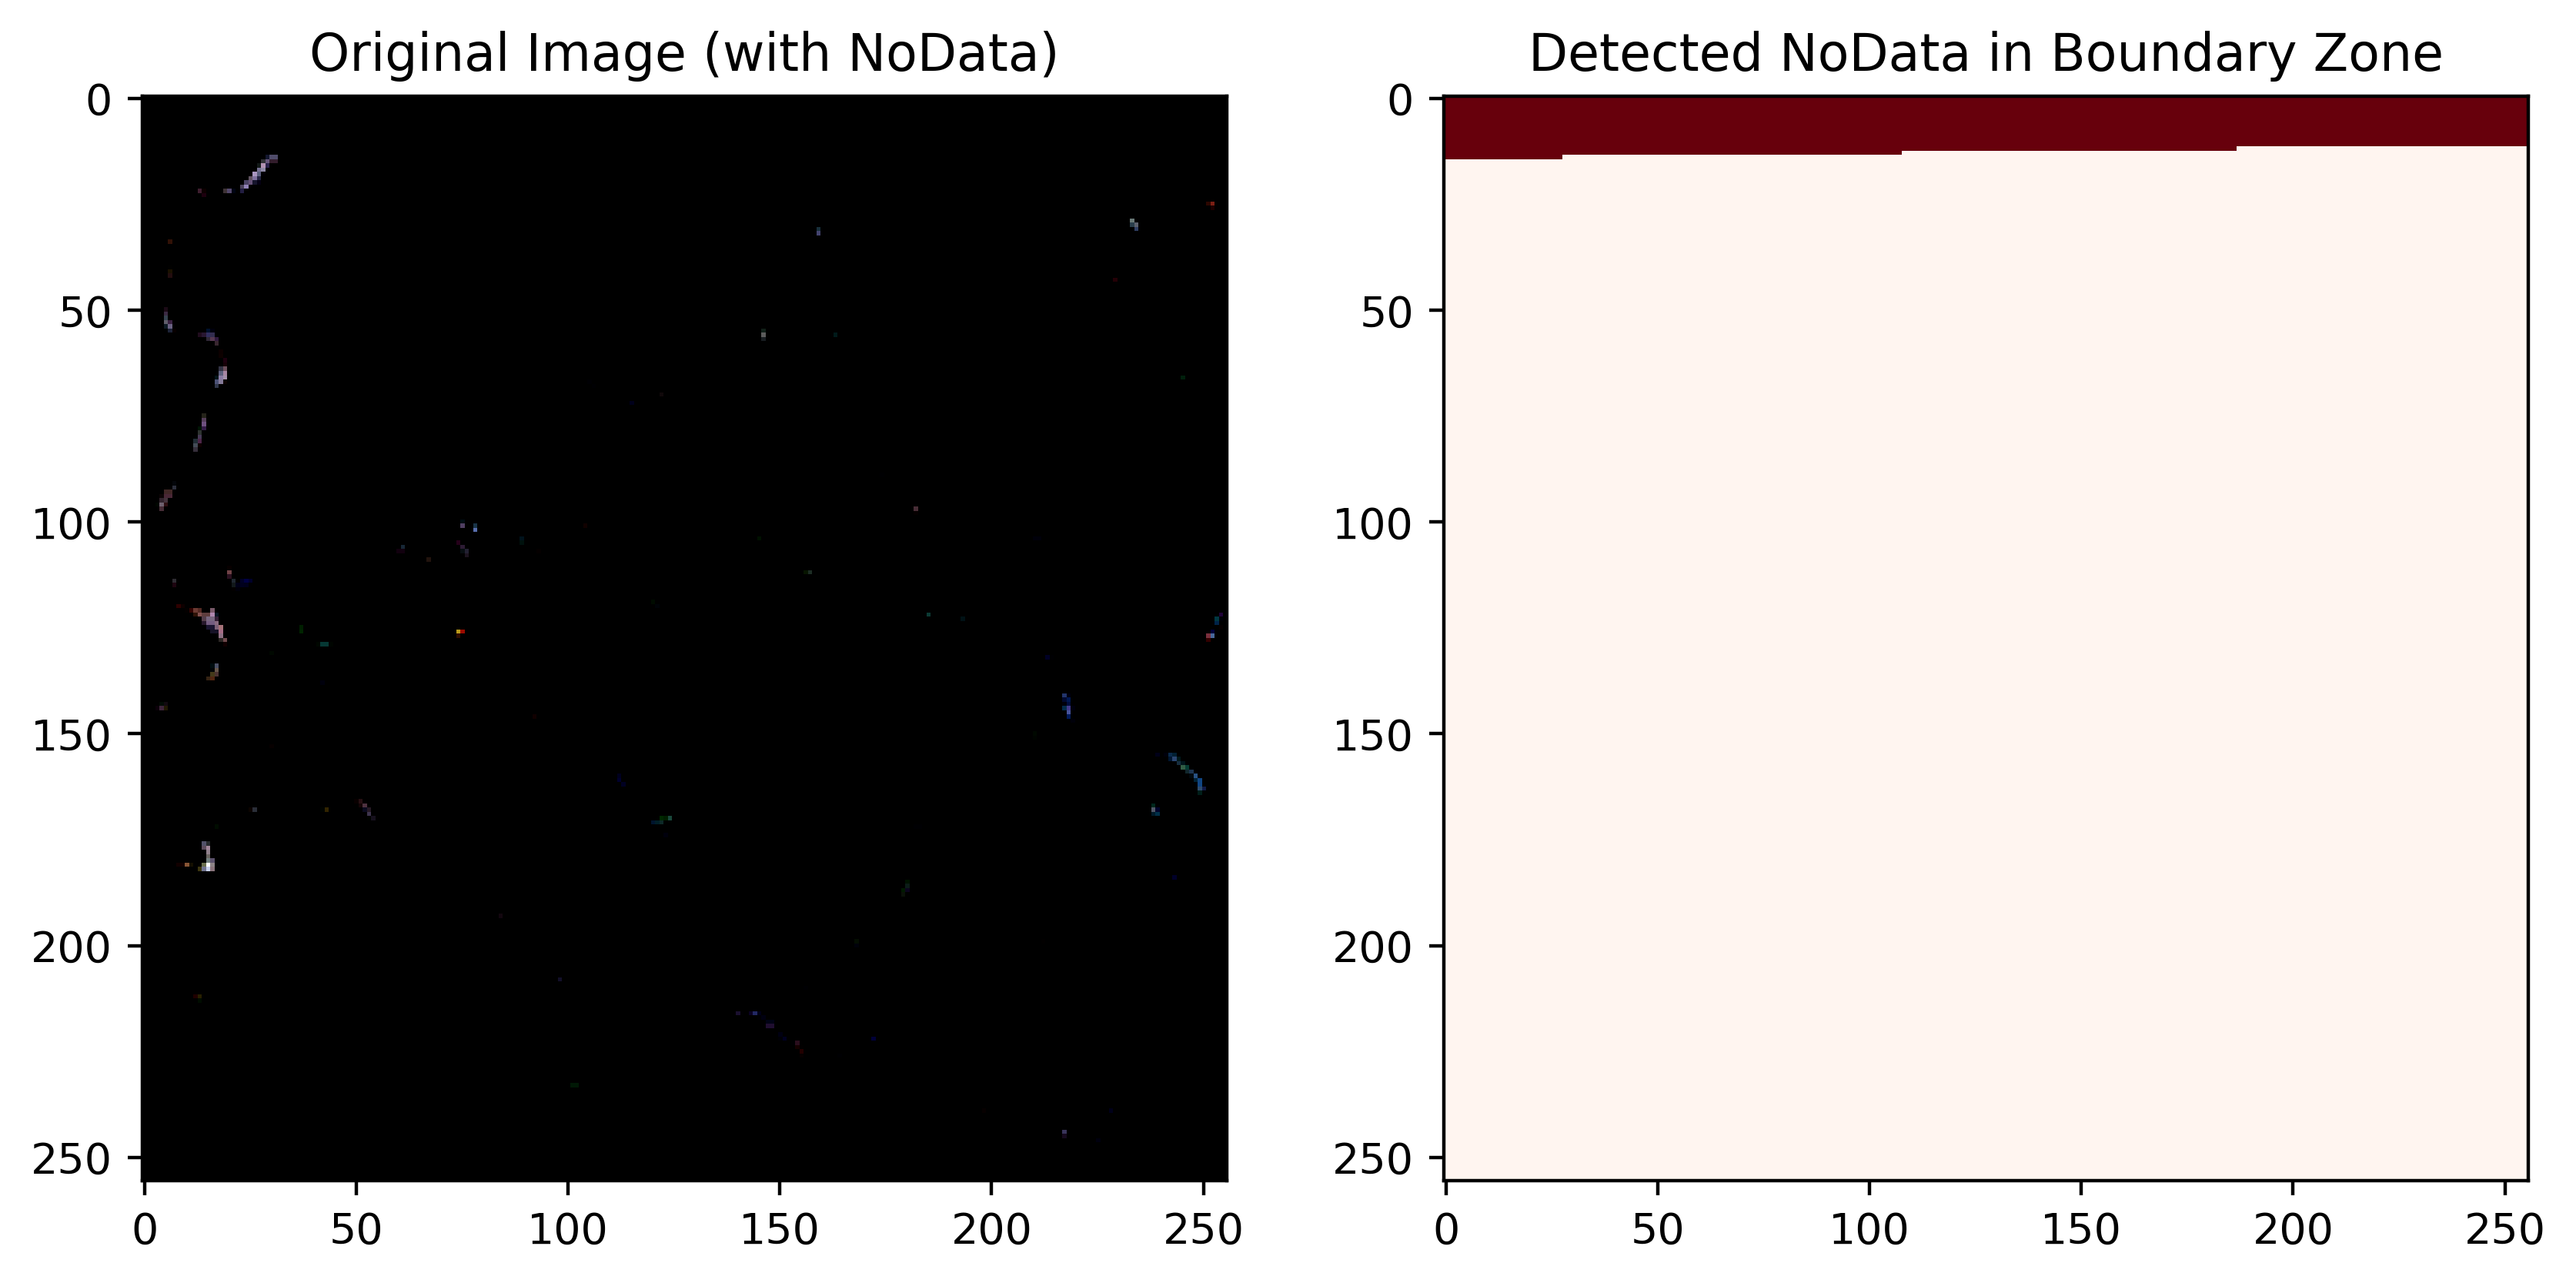

Boundary NoData detected for ROI: Burundi_post


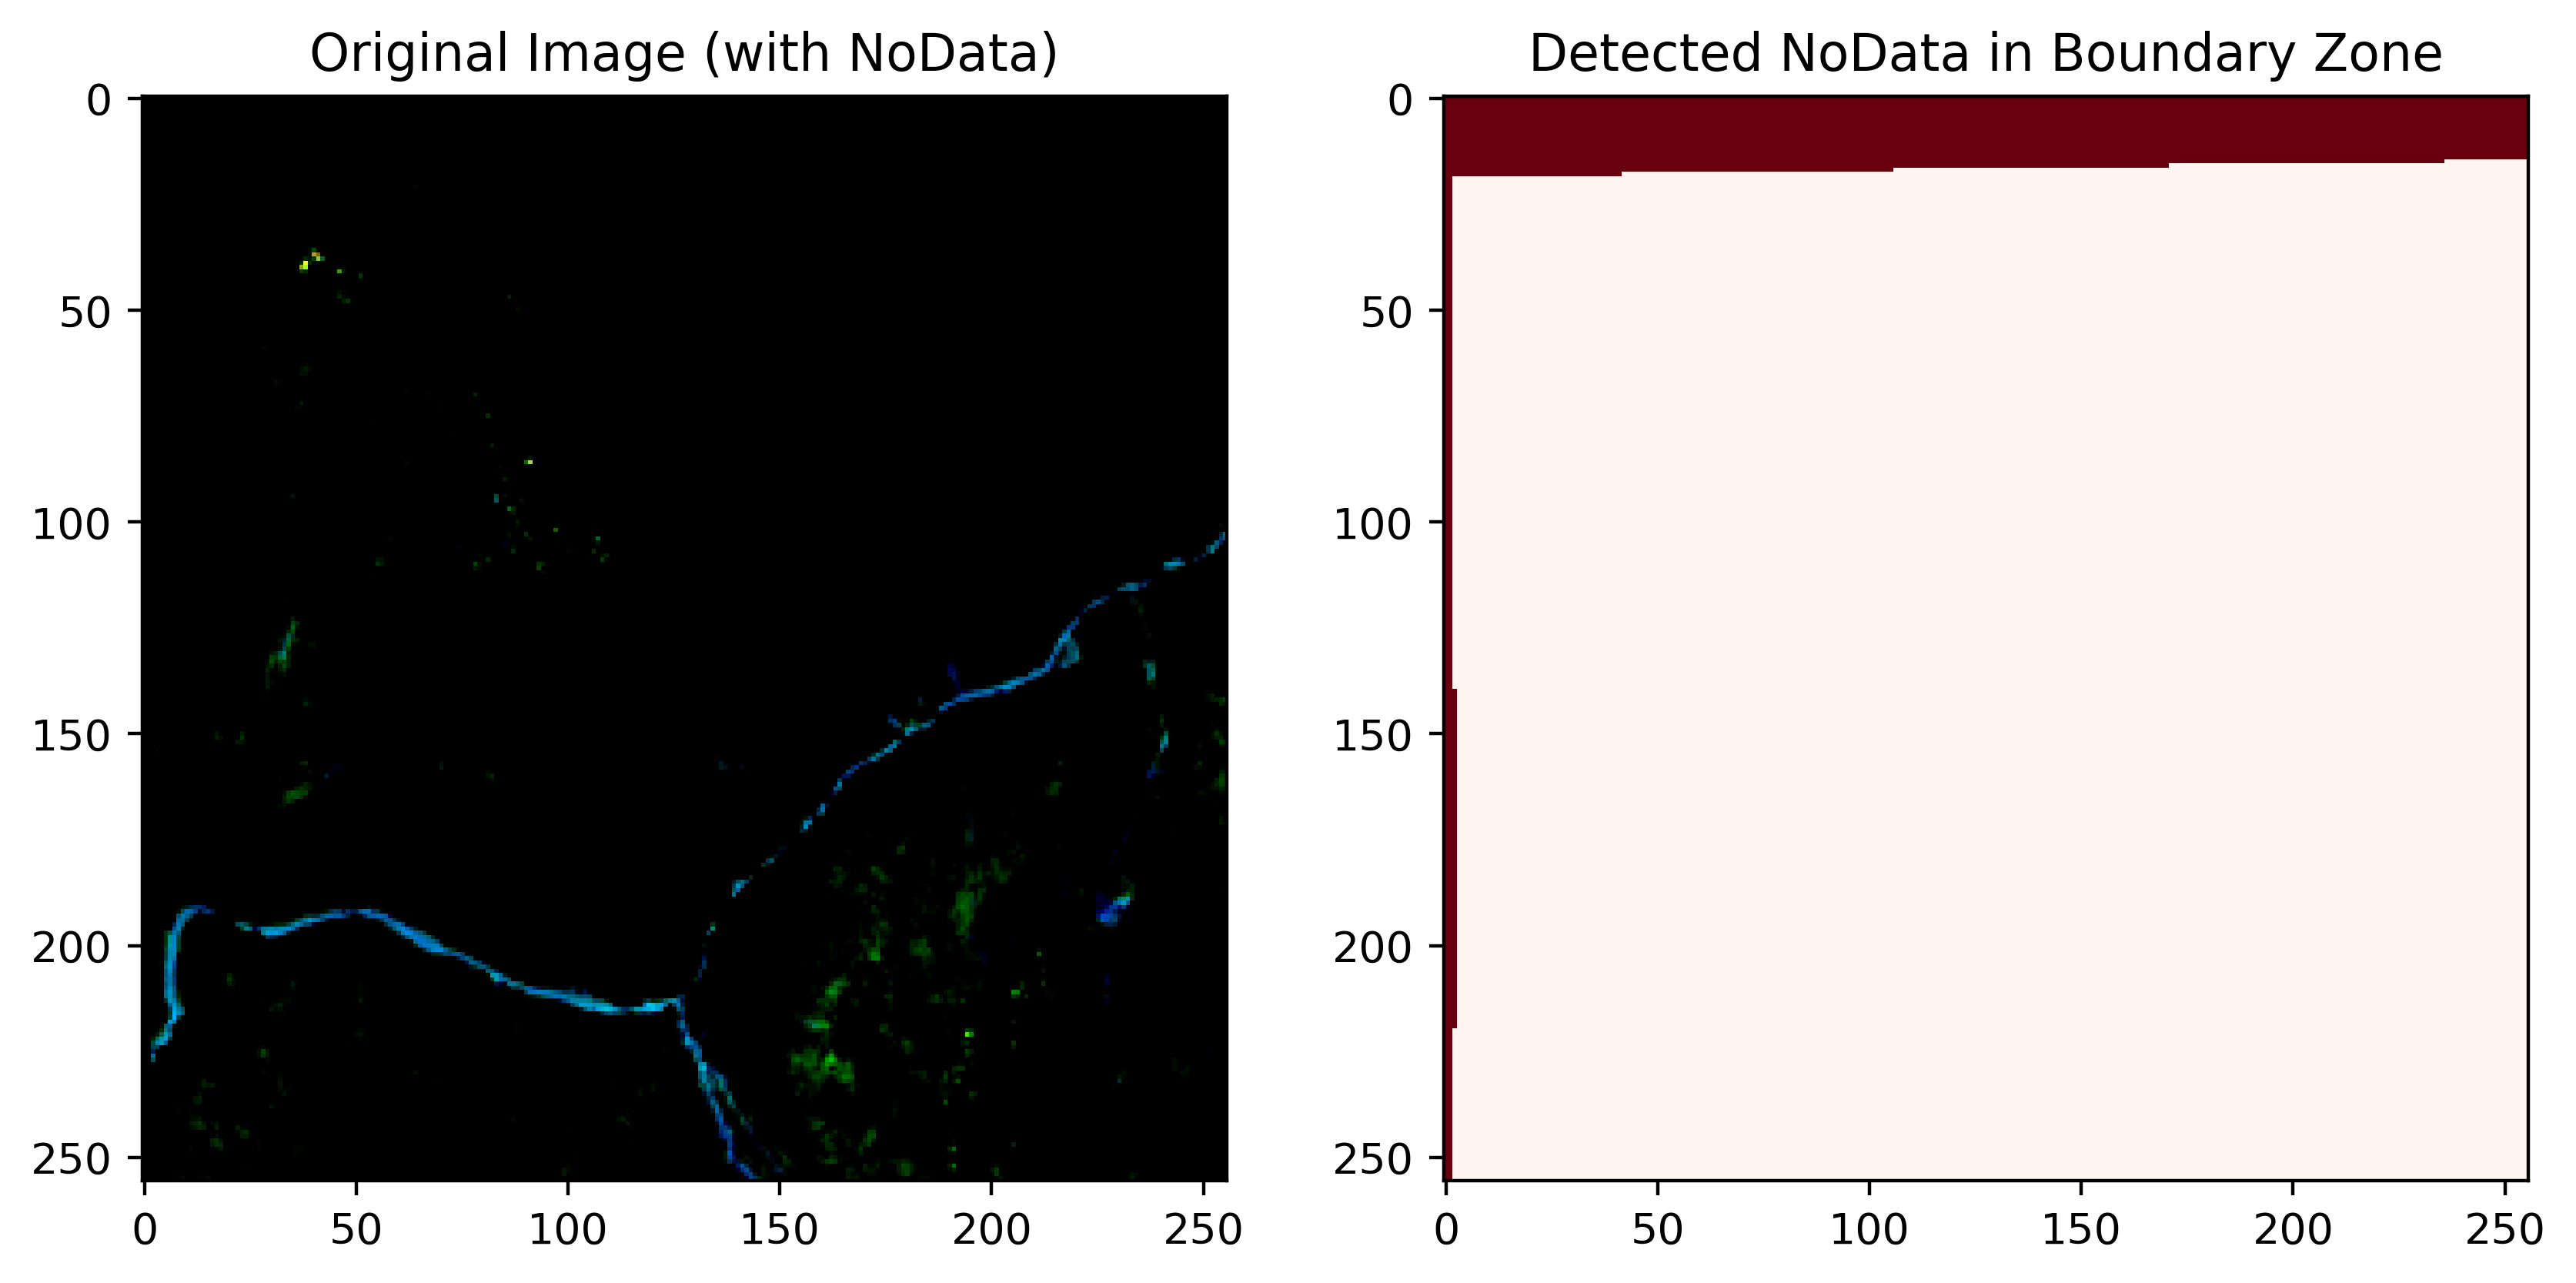

Boundary NoData detected for ROI: Butangbunasi_post


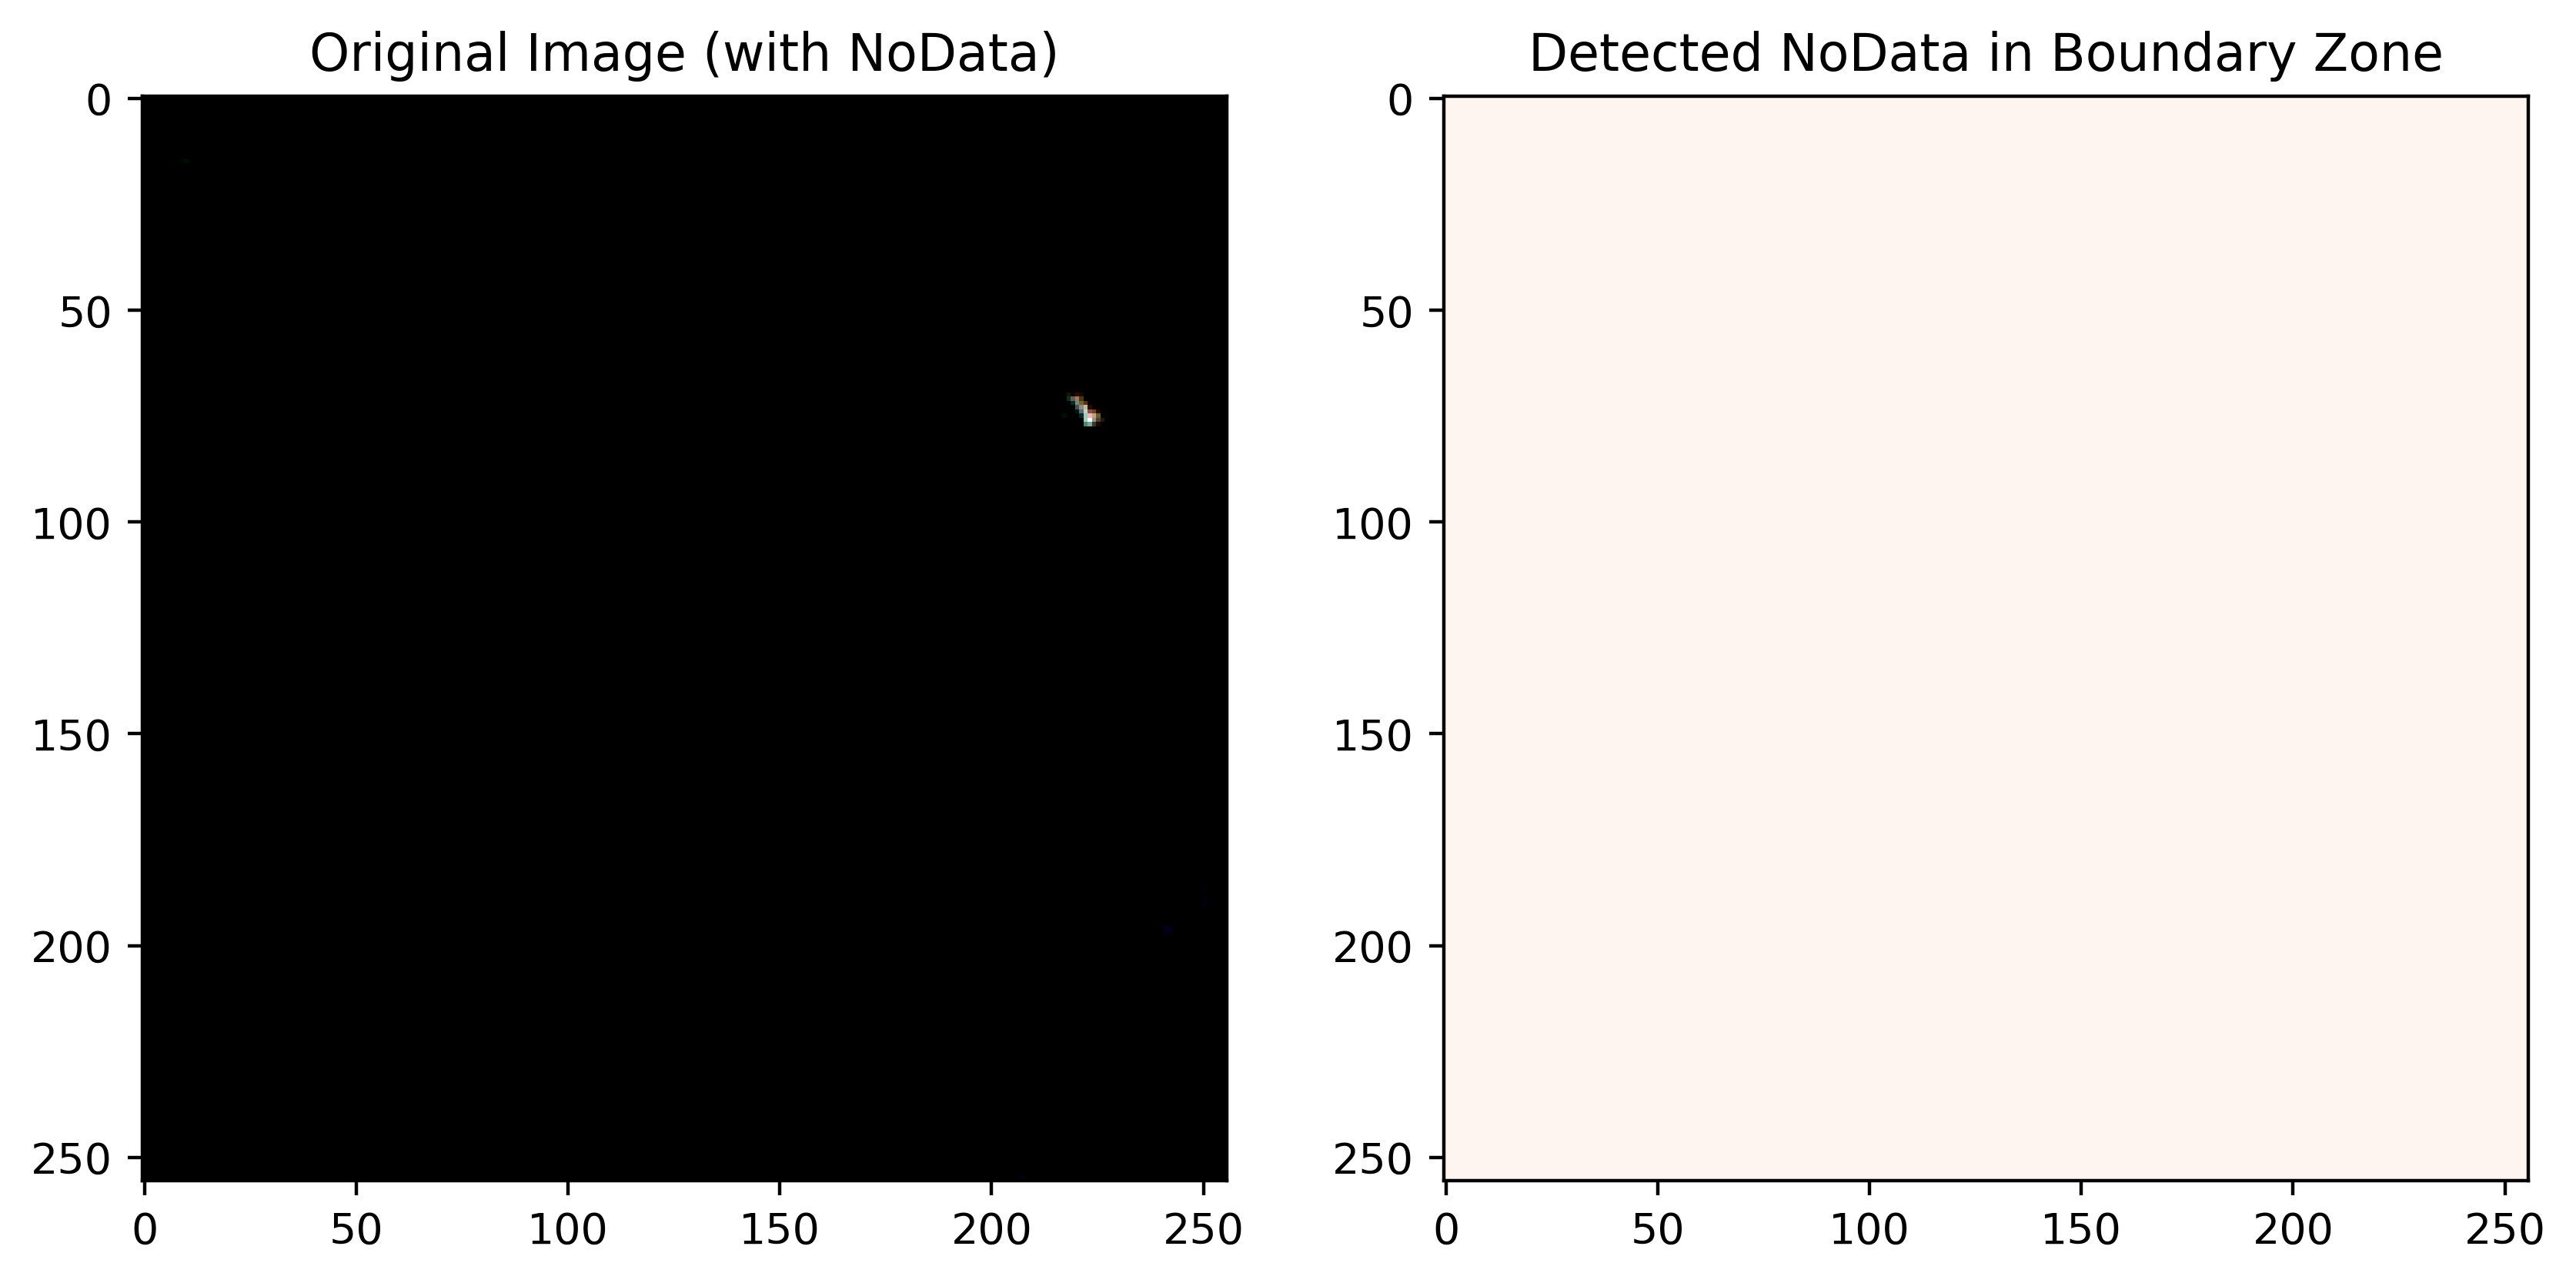

Boundary NoData detected for ROI: Dominica_post_1


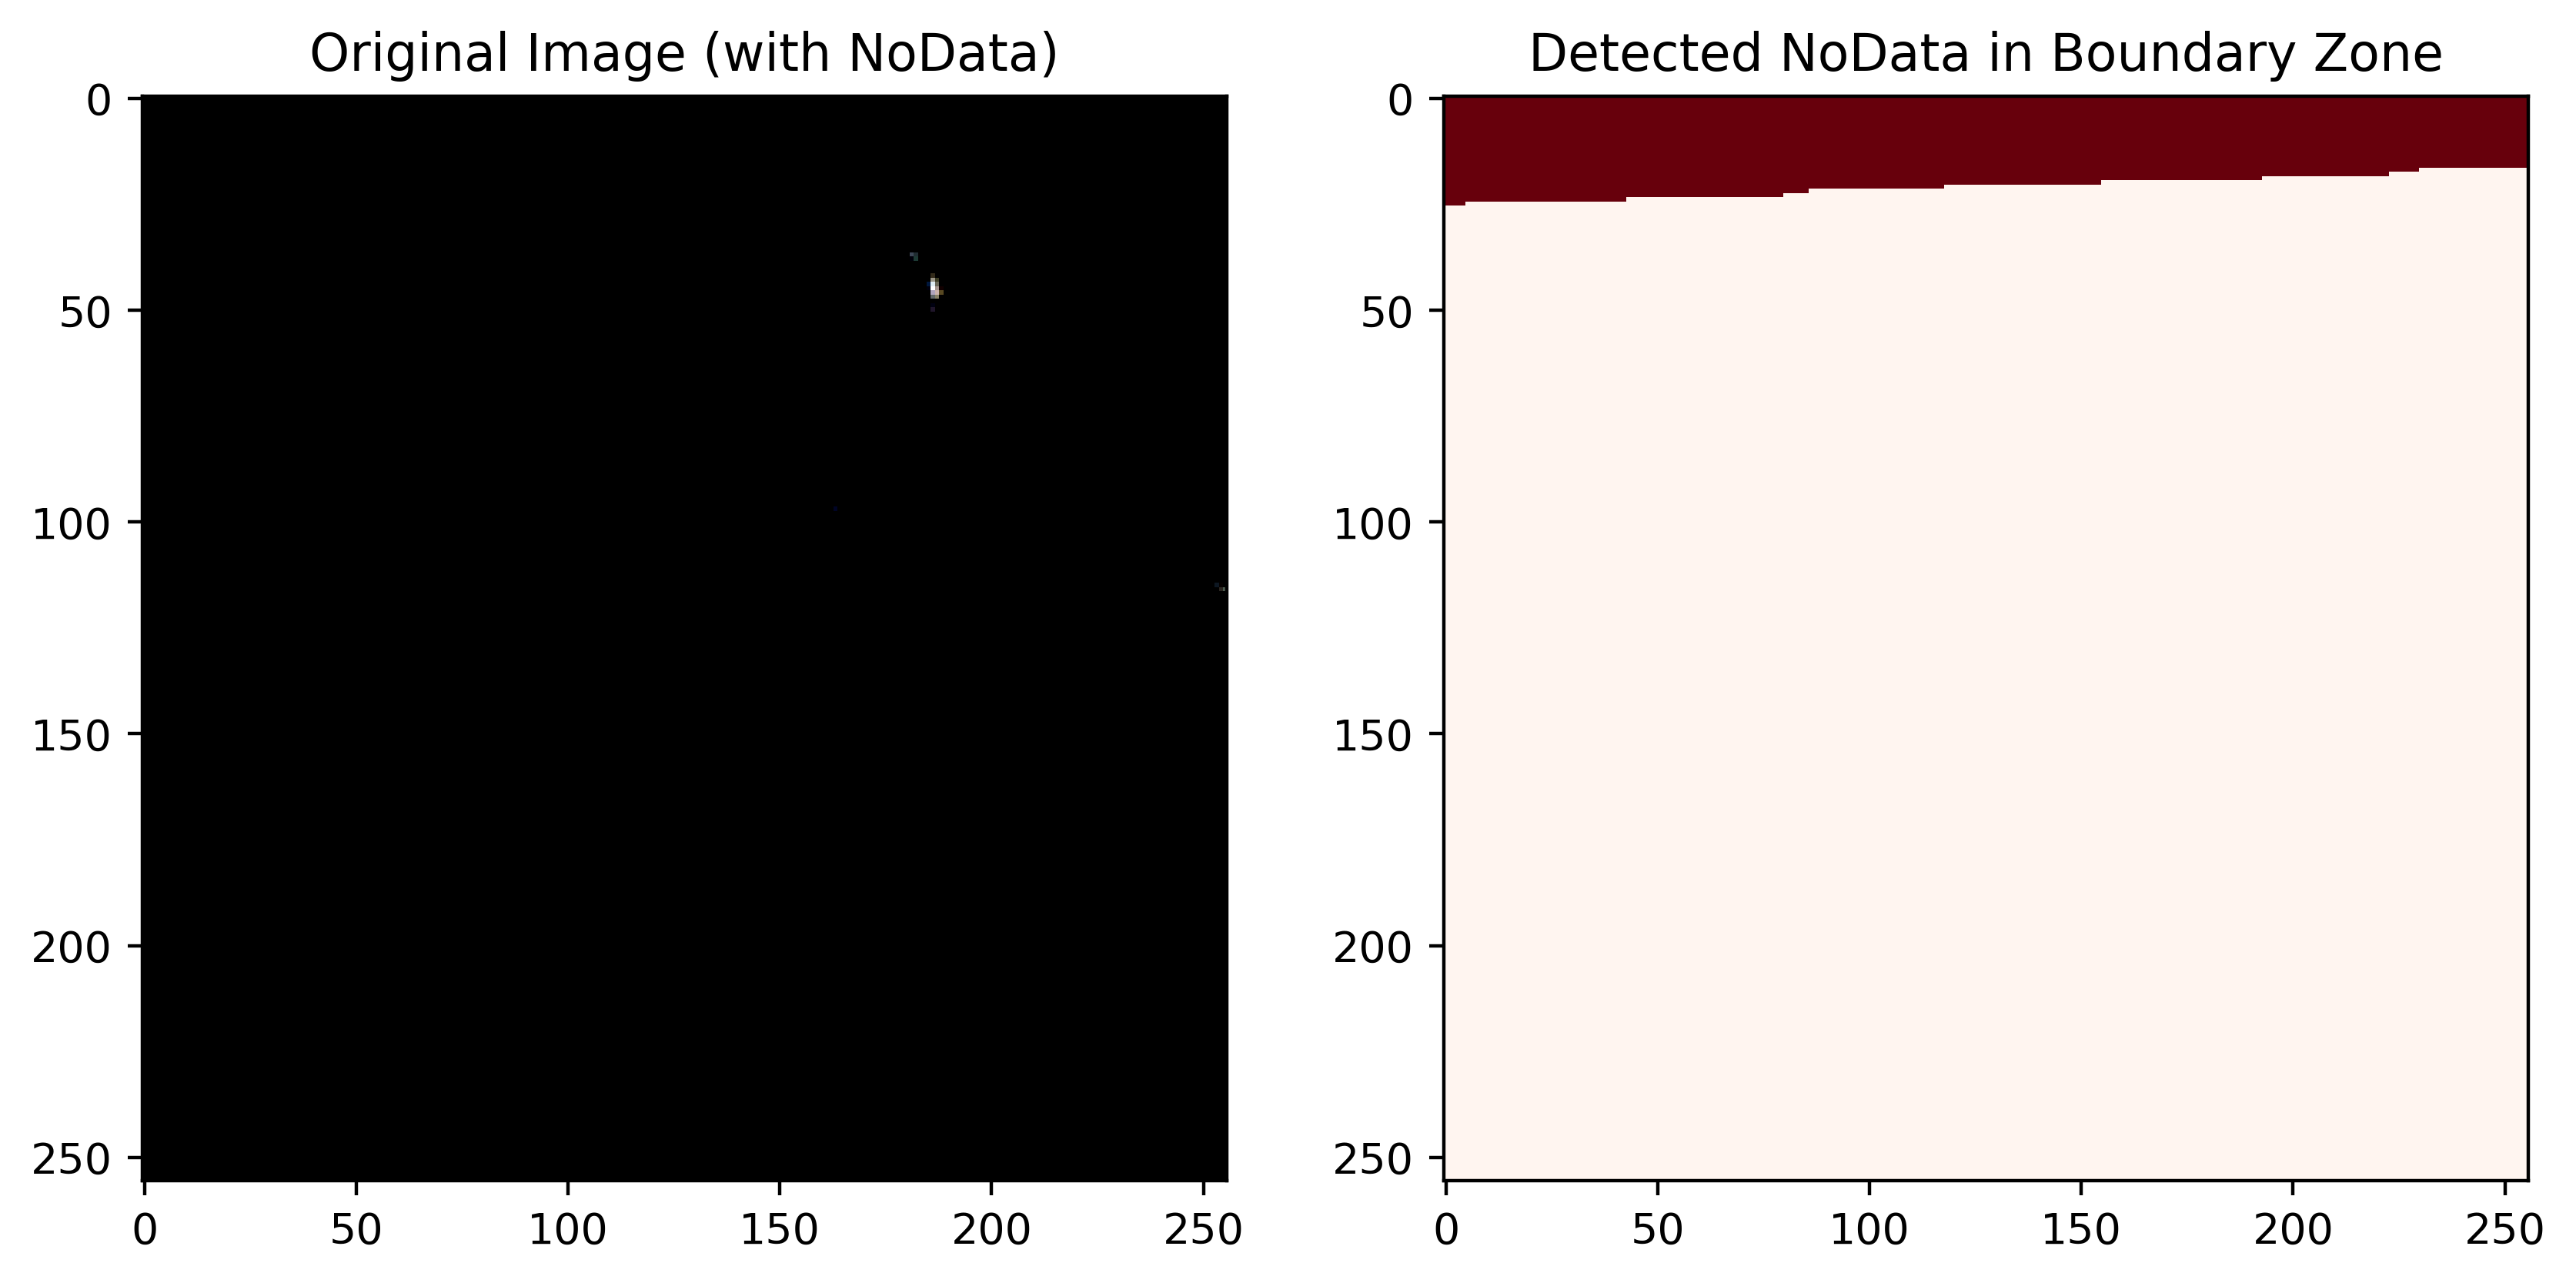

Boundary NoData detected for ROI: Dominica_post_2


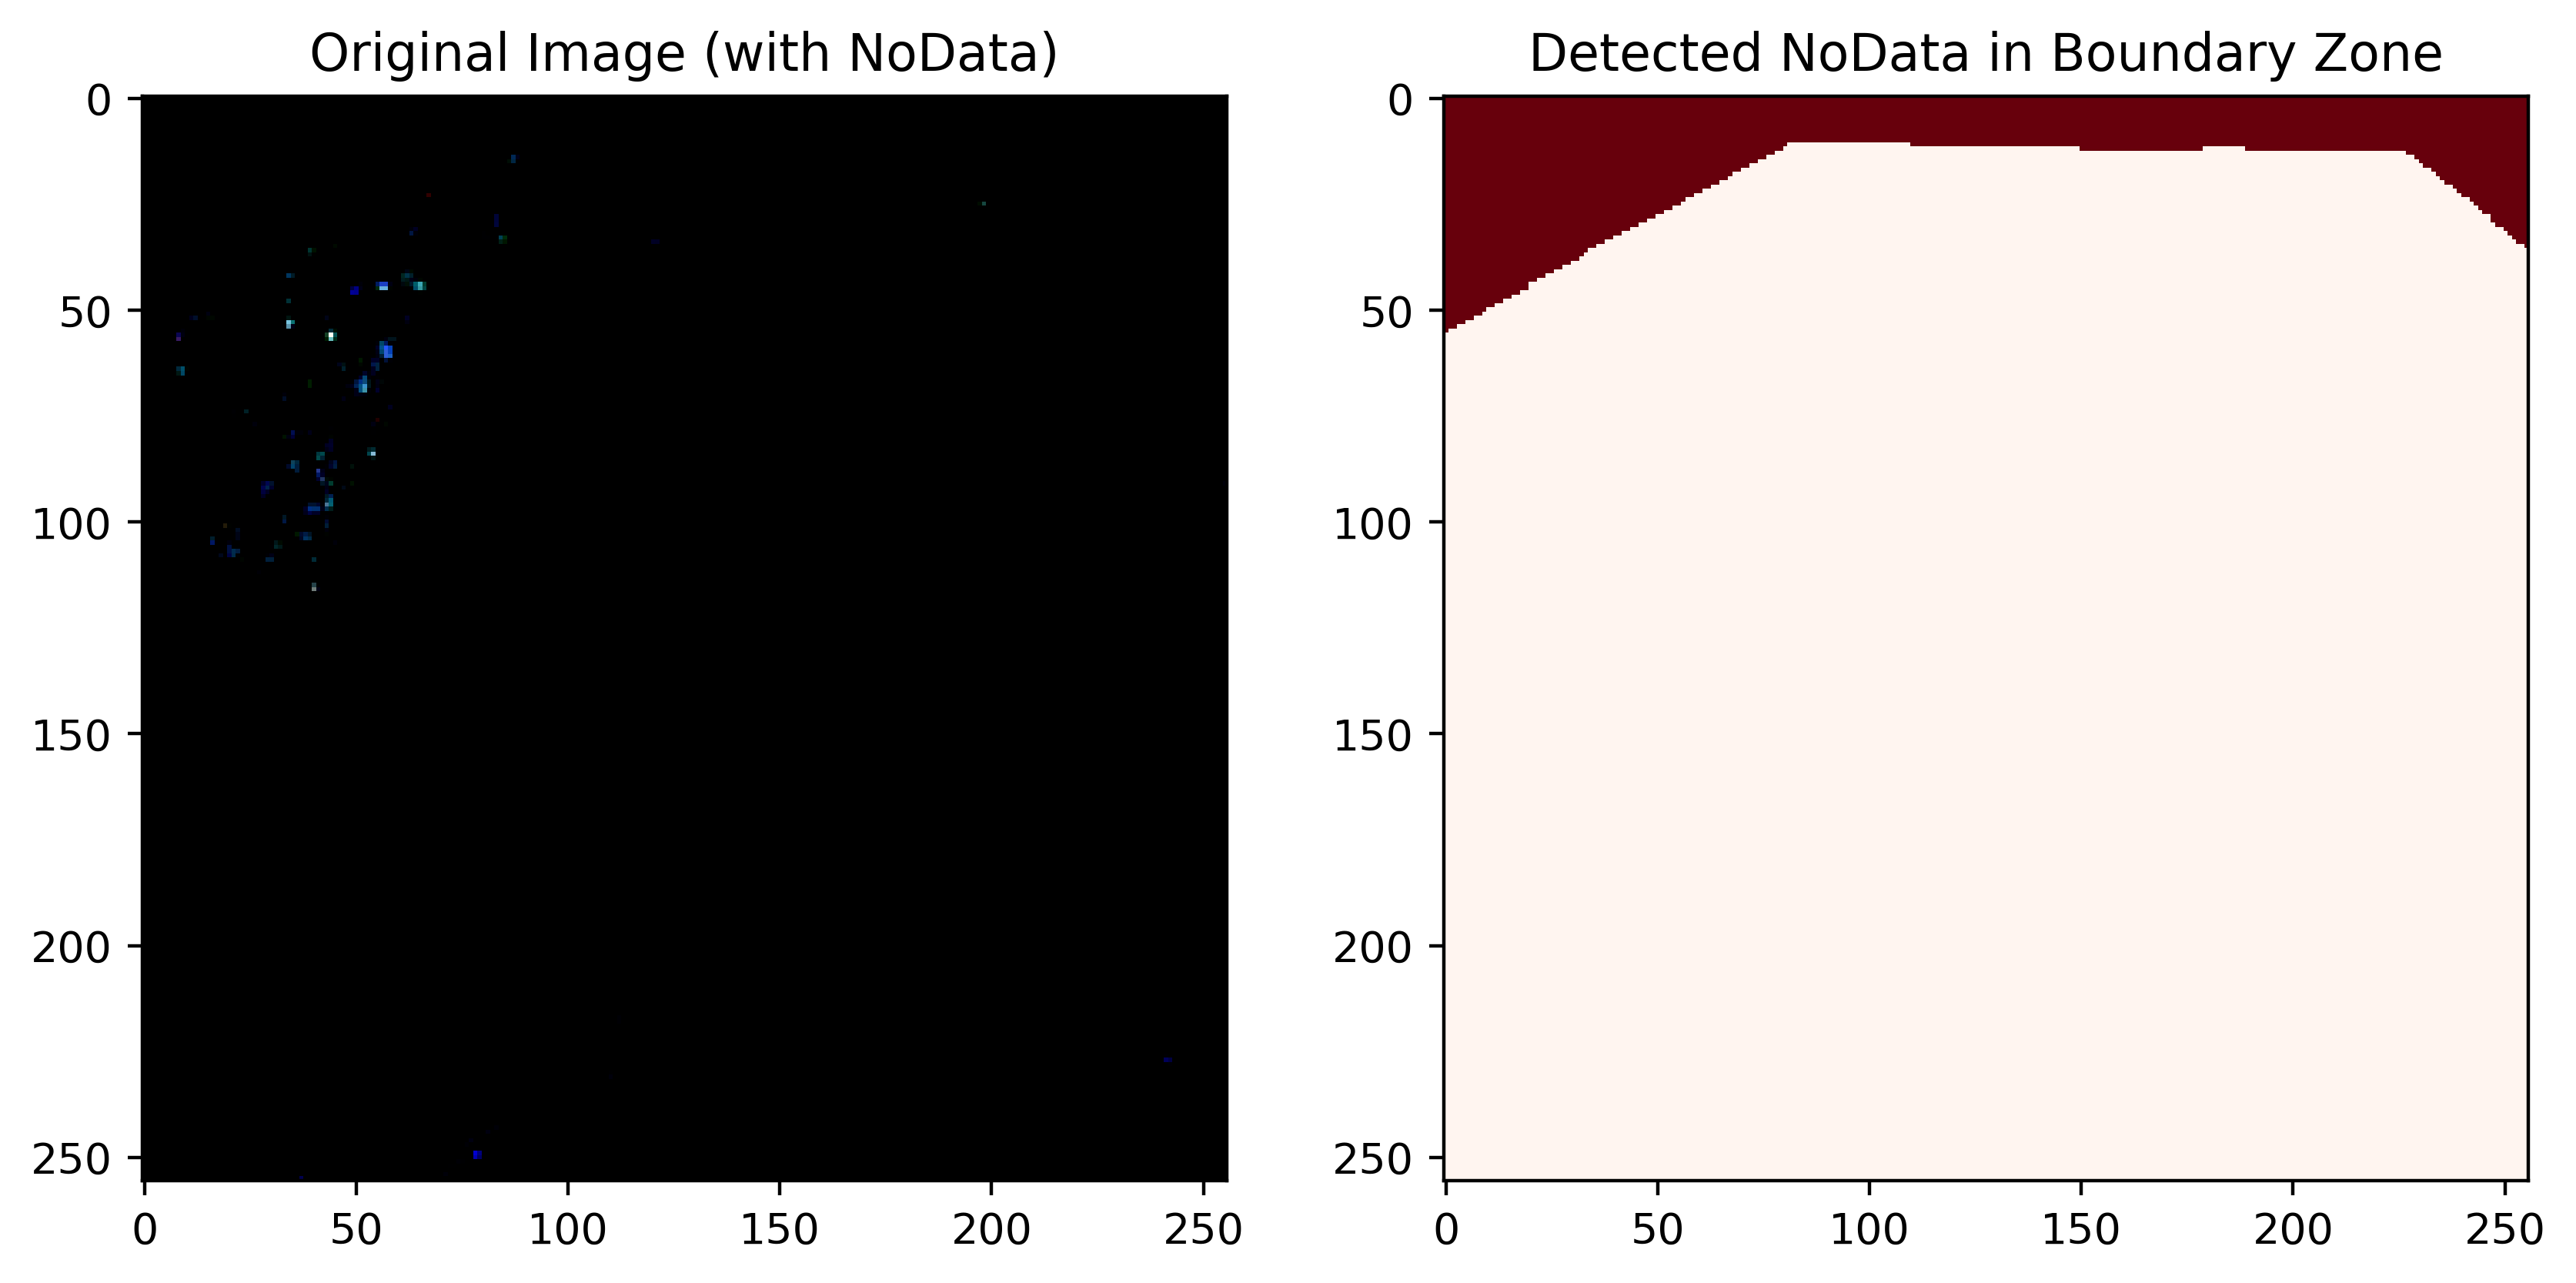

In [ ]:
def detect_boundary_nodata(image, research_fraction=0.15):
    height, width, _ = image.shape
    boundary_height = int(research_fraction * height)
    boundary_width = int(research_fraction * width)

    # Detect NaN pixels in the first band
    nodata_mask = np.isnan(image[:, :, 0])  # Only check the first band for NoData

    # Define boundary zones directly using slicing
    boundary_nodata_mask = np.zeros((height, width), dtype=bool)
    boundary_nodata_mask[:boundary_height, :] |= nodata_mask[:boundary_height, :]  # Top
    boundary_nodata_mask[-boundary_height:, :] |= nodata_mask[-boundary_height:, :]  # Bottom
    boundary_nodata_mask[:, :boundary_width] |= nodata_mask[:, :boundary_width]  # Left
    boundary_nodata_mask[:, -boundary_width:] |= nodata_mask[:, -boundary_width:]  # Right

    return boundary_nodata_mask


def visualize_boundary_nodata(image, boundary_nodata_mask):

    plt.figure(figsize=(10, 5))
    # Visualize original image
    plt.subplot(1, 2, 1)
    plt.imshow(np.nan_to_num(image[:, :, :3], nan=0))  # Use RGB composite
    plt.title("Original Image (with NoData)")

    # Visualize detected NoData
    plt.subplot(1, 2, 2)
    mask_visual = np.zeros_like(image[:, :, 0])
    mask_visual[boundary_nodata_mask] = 1
    plt.imshow(mask_visual, cmap='Reds')
    plt.title("Detected NoData in Boundary Zone")
    plt.show()

# Create a dictionary to store boundary masks
boundary_masks = {}

for roi_name, patches in filtered_images1.items():
    boundary_masks[roi_name] = [
        detect_boundary_nodata(patch) for patch in patches
    ]

# Select the first image patch from the first five ROIs and visualize
selected_rois = list(filtered_images1.keys())[:5]  # First five ROIs
for roi_name in selected_rois:
    patches = filtered_images1[roi_name]
    first_patch = patches[0]  # Select the first patch

    # Get the boundary NoData mask for the first patch
    boundary_nodata_mask = boundary_masks[roi_name][0]

    print(f"Boundary NoData detected for ROI: {roi_name}")
    visualize_boundary_nodata(first_patch, boundary_nodata_mask)


In [ ]:
from scipy.spatial import QhullError
from scipy.spatial import distance

In [25]:
# OpenCV Inpainting
def openCV_inpainting(image, inpaint_radius=3):
    inpainted_image = np.empty_like(image)

    for band in range(image.shape[-1]):
        single_band = image[:, :, band]
        nan_mask = np.isnan(single_band).astype(np.uint8)  # Mask for NaN values

        single_band_filled = cv2.inpaint(
            np.nan_to_num(single_band, nan=0).astype(np.float32),
            nan_mask,
            inpaint_radius,
            cv2.INPAINT_TELEA
        )
        inpainted_image[:, :, band] = single_band_filled

    return inpainted_image

# KNN Imputation
def knn_imputation(image, n_neighbors=5):
    flat_image = image.reshape(-1, image.shape[-1])
    knn_imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_flat_image = knn_imputer.fit_transform(flat_image)
    return imputed_flat_image.reshape(image.shape)

# Threshold Calculation
def calculate_threshold(original_image, alpha=1.0):
    mean = np.nanmean(original_image, axis=(0, 1))
    variance = np.nanvar(original_image, axis=(0, 1))
    return np.minimum(mean - alpha * np.sqrt(variance), mean + alpha * np.sqrt(variance))

# Nearest Valid Pixel Finder (optimized using KDTree)
def find_nearest_valid_pixel(image, i, j, band):
    valid_mask = ~np.isnan(image[:, :, band])
    valid_coords = np.column_stack(np.where(valid_mask))

    tree = KDTree(valid_coords)
    _, nearest_index = tree.query([i, j], k=1)

    nearest_valid_value = image[valid_coords[nearest_index][0], valid_coords[nearest_index][1], band]
    return nearest_valid_value

# Validation Check
def is_close_to_nearest_valid(value, nearest_valid_value, threshold):
    return abs(value - nearest_valid_value) < threshold

# Hybrid Fusion
def hybrid_fusion(image, original_image, inpaint_radius=5, knn_neighbors=5, alpha=1.0):
    inpainted_image = openCV_inpainting(image, inpaint_radius)
    knn_imputed_image = knn_imputation(image, knn_neighbors)
    threshold = calculate_threshold(original_image, alpha)

    fused_image = np.copy(knn_imputed_image)
    for band in range(image.shape[-1]):
        nan_mask = np.isnan(image[:, :, band])

        for i, j in zip(*np.where(nan_mask)):
            inpainted_value = inpainted_image[i, j, band]
            knn_imputed_value = knn_imputed_image[i, j, band]
            nearest_valid_value = find_nearest_valid_pixel(original_image, i, j, band)

            if not np.isnan(inpainted_value):
                if is_close_to_nearest_valid(inpainted_value, nearest_valid_value, threshold[band]):
                    fused_image[i, j, band] = inpainted_value
                else:
                    fused_image[i, j, band] = np.mean([inpainted_value, knn_imputed_value])
            else:
                fused_image[i, j, band] = knn_imputed_value

    return fused_image

def replace_nodata_boundary(image,original_image, inpaint_radius=5, knn_neighbors=5, alpha=1.0):

    height, width, bands = image.shape
    boundary_mask = detect_boundary_nodata(image)

    # Get indices of boundary NoData
    boundary_indices = np.argwhere(boundary_mask)

    if len(boundary_indices) >= 3:
        try:
            hull = ConvexHull(boundary_indices)
            if len(hull.vertices) <= 5:  # Simple shape
                # Replace boundary NoData with white pixel value
                for band in range(bands):
                    image[np.isnan(image[:, :, band]) & boundary_mask, band] = 1.0
            else:
                # Apply hybrid_inpainting for complex shapes
                image = hybrid_fusion(image, original_image, inpaint_radius, knn_neighbors, alpha)
        except QhullError:
            # If ConvexHull fails, apply hybrid_inpainting
            image = hybrid_fusion(image, original_image, inpaint_radius, knn_neighbors, alpha)
    else:
        # Apply hybrid_inpainting for inner NoData regions
        image = hybrid_fusion(image, original_image, inpaint_radius, knn_neighbors, alpha)

    return image

# Process Image Patches
def process_image_patches(roi_dict, inpaint_radius=3, knn_neighbors=5, alpha=1.0):
    def process_single_patch(patch):
        return replace_nodata_boundary(
            np.copy(patch), patch, inpaint_radius, knn_neighbors, alpha
        )

    imputed_rois = {}
    for roi_name, image_stack in roi_dict.items():
        print(f"Processing ROI: {roi_name} with {image_stack.shape[0]} patches")
        imputed_patches = Parallel(n_jobs=-1)(
            delayed(process_single_patch)(image_stack[i]) for i in range(image_stack.shape[0])
        )
        imputed_rois[roi_name] = np.array(imputed_patches)

    return imputed_rois


In [52]:
def openCV_inpainting(image, inpaint_radius=3):

    inpainted_image = np.empty_like(image)

    for band in range(image.shape[-1]):
        single_band = image[:, :, band]
        nan_mask = np.isnan(single_band).astype(np.uint8)  # Mask for NaN values

        # Inpaint using OpenCV's Telea method
        single_band_filled = cv2.inpaint(
            np.nan_to_num(single_band, nan=0).astype(np.float32),
            nan_mask,
            inpaint_radius,
            cv2.INPAINT_TELEA
        )
        inpainted_image[:, :, band] = single_band_filled

    return inpainted_image

def knn_imputation(image, n_neighbors=5):

    # Flatten the image for KNN
    flat_image = image.reshape(-1, image.shape[-1])

    # Apply KNN imputer
    knn_imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_flat_image = knn_imputer.fit_transform(flat_image)

    # Reshape back to the original image shape
    imputed_image = imputed_flat_image.reshape(image.shape)
    return imputed_image

def calculate_threshold(original_image, alpha=1.0):

    mean = np.nanmean(original_image, axis=(0, 1))  # Mean for each band
    variance = np.nanvar(original_image, axis=(0, 1))  # Variance for each band
    # Apply the minimum value element-wise to the threshold array
    threshold = np.minimum(mean - alpha * np.sqrt(variance), mean + alpha * np.sqrt(variance))
    return threshold

def find_nearest_valid_pixel(image, i, j, band):

    # Create a mask to identify valid pixels (not NaN)
    valid_mask = ~np.isnan(image[:, :, band])

    # Get the coordinates of the valid pixels
    valid_coords = np.column_stack(np.where(valid_mask))

    # Get the coordinates of the target pixel
    target_coords = np.array([i, j])

    # Compute the distances from the target pixel to all valid pixels
    dist = distance.cdist([target_coords], valid_coords, 'euclidean')

    # Get the index of the closest valid pixel
    nearest_valid_index = np.argmin(dist)

    # Get the value of the nearest valid pixel
    nearest_valid_value = image[valid_coords[nearest_valid_index][0], valid_coords[nearest_valid_index][1], band]

    return nearest_valid_value

def is_close_to_nearest_valid(value, nearest_valid_value, threshold):

    return abs(value - nearest_valid_value) < threshold

def hybrid_fusion(image, original_image, inpaint_radius=3, knn_neighbors=5, alpha=1.0):

    # Step 1: Apply OpenCV inpainting to handle small structured gaps
    inpainted_image = openCV_inpainting(image, inpaint_radius)

    # Step 2: Apply KNN imputation to handle larger or more complex gaps
    knn_imputed_image = knn_imputation(image, knn_neighbors)

    # Step 3: Calculate threshold based on original image
    threshold = calculate_threshold(original_image, alpha)
    #print(threshold)

    # Step 4: Combine both results based on the conditions:
    fused_image = np.copy(knn_imputed_image)  # Start with KNN results

    for band in range(image.shape[-1]):
        # Mask where the original image had NaN values
        nan_mask = np.isnan(image[:, :, band])

        for i, j in zip(*np.where(nan_mask)):
            inpainted_value = inpainted_image[i, j, band]
            knn_imputed_value = knn_imputed_image[i, j, band]

            # Find the nearest valid value in the original image for this pixel
            nearest_valid_value = find_nearest_valid_pixel(original_image, i, j, band)

            if not np.isnan(inpainted_value):  # If OpenCV inpainting filled this pixel
                if is_close_to_nearest_valid(inpainted_value, nearest_valid_value, threshold[band]):
                    fused_image[i, j, band] = inpainted_value  # Use inpainted value
                else:
                    fused_image[i, j, band] = np.mean([inpainted_value, knn_imputed_value])  # Take the mean
            else:
                # If OpenCV didn't fill this pixel, rely on KNN
                fused_image[i, j, band] = knn_imputed_value

    return fused_image

def replace_nodata_boundary(image,original_image, n_neighbors=5, inpaint_radius=3, knn_neighbors=5, alpha=1.0):

    height, width, bands = image.shape
    boundary_mask = detect_boundary_nodata(image)

    # Get indices of boundary NoData
    boundary_indices = np.argwhere(boundary_mask)

    if len(boundary_indices) >= 3:
        try:
            hull = ConvexHull(boundary_indices)
            if len(hull.vertices) <= 5:  # Simple shape
                # Replace boundary NoData with white pixel value
                for band in range(bands):
                    image[np.isnan(image[:, :, band]) & boundary_mask, band] = 0.0
            else:
                # Apply hybrid_inpainting for complex shapes
                image = hybrid_fusion(image, original_image, inpaint_radius=3, knn_neighbors=5, alpha=1.0)
        except QhullError:
            # If ConvexHull fails, apply hybrid_inpainting
            image = hybrid_fusion(image, original_image, inpaint_radius=3, knn_neighbors=5, alpha=1.0)
    else:
        # Apply hybrid_inpainting for inner NoData regions
        image = hybrid_fusion(image, original_image, inpaint_radius=3, knn_neighbors=5, alpha=1.0)

    return image

def process_image_patches(roi_dict, inpaint_radius=3, knn_neighbors=5, alpha=1.0):

    imputed_rois = {}

    for roi_name, image_stack in roi_dict.items():
        print(f"Processing ROI: {roi_name} with {image_stack.shape[0]} patches")
        imputed_patches = []

        for i in range(image_stack.shape[0]):
            original_image = image_stack[i]
            imputed_image = replace_nodata_boundary(
                np.copy(original_image), original_image, inpaint_radius, knn_neighbors, alpha
            )
            imputed_patches.append(imputed_image)

        imputed_rois[roi_name] = np.array(imputed_patches)

    return imputed_rois


In [59]:
filtered_images1 = process_image_patches(filtered_images1)
filtered_images3 = process_image_patches(filtered_images3)

Processing ROI: Agatha_post with 116 patches
Processing ROI: Burundi_post with 38 patches
Processing ROI: Butangbunasi_post with 20 patches
Processing ROI: Dominica_post_1 with 244 patches
Processing ROI: Dominica_post_2 with 74 patches
Processing ROI: Emilia_post with 302 patches
Processing ROI: Haiti_post_1 with 157 patches
Processing ROI: Haiti_post_2 with 246 patches
Processing ROI: Honduras_post with 54 patches
Processing ROI: India_post with 26 patches
Processing ROI: Itogon_post with 13 patches
Processing ROI: Japan_post with 170 patches
Processing ROI: Kenya_post with 101 patches
Processing ROI: Lanao_post with 6 patches
Processing ROI: Luding_post with 273 patches
Processing ROI: Maerkang_post with 41 patches
Processing ROI: Marche_post with 34 patches
Processing ROI: Nepal_post with 48 patches
Processing ROI: Otis_post with 29 patches
Processing ROI: Pacific_NW_post with 4 patches
Processing ROI: Palu_post with 45 patches
Processing ROI: Papua_post with 199 patches
Processing

In [49]:
filtered_images2 = process_image_patches(filtered_images2)

Processing ROI: Agatha_DEM with 116 patches
Processing ROI: Burundi_DEM with 38 patches
Processing ROI: Butangbunasi_DEM with 20 patches
Processing ROI: Dominica_DEM_1 with 244 patches
Processing ROI: Dominica_DEM_2 with 74 patches
Processing ROI: Emilia_DEM with 302 patches
Processing ROI: Haiti_DEM_1 with 157 patches
Processing ROI: Haiti_DEM_2 with 246 patches
Processing ROI: Honduras_DEM with 54 patches
Processing ROI: India_DEM with 26 patches
Processing ROI: Itogon_DEM with 13 patches
Processing ROI: Japan_DEM with 170 patches
Processing ROI: Kenya_DEM with 101 patches
Processing ROI: Lanao_DEM with 6 patches
Processing ROI: Luding_DEM with 273 patches
Processing ROI: Maerkang_DEM with 41 patches
Processing ROI: Marche_DEM with 34 patches
Processing ROI: Nepal_DEM with 48 patches
Processing ROI: Otis_DEM with 29 patches
Processing ROI: Pacific_NW_DEM with 4 patches
Processing ROI: Palu_DEM with 45 patches
Processing ROI: Papua_DEM with 199 patches
Processing ROI: Rwanda_DEM with 

In [27]:
# Find NaN values in the array
def find_nodata(image_dict):
    nan_indices_dict = {}  # Dictionary to store indices of NaN values for each ROI

    for roi_name, image_array in image_dict.items():

        # Find indices of NaN values
        nan_indices = np.where(np.isnan(image_array))

        # Store the  NaN indices
        nan_indices_dict[roi_name] = nan_indices

    return nan_indices_dict


nan_indices1 = find_nodata(filtered_images1)
nan_indices2 = find_nodata(filtered_images2)
nan_indices3 = find_nodata(filtered_images3)

# Print NaN indices for each ROI
for roi_name, nan_indices in nan_indices1.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

for roi_name, nan_indices in nan_indices2.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

ROI: Agatha_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Burundi_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Butangbunasi_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Dominica_post_1
Indices of NaN values: (array([243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243, 243,
       243, 243, 243, 243, 243, 2

In [30]:
def replace_nodata_with_zero(image_dict):

    updated_dict = {}
    for roi_name, image_array in image_dict.items():
        # Replace NaN values with 0 using np.nan_to_num
        updated_array = np.nan_to_num(image_array, nan= 1.0)
        updated_dict[roi_name] = updated_array
    return updated_dict

In [29]:
# Apply the function to your image dictionaries
filtered_images1 = replace_nodata_with_zero(filtered_images1)
filtered_images3 = replace_nodata_with_zero(filtered_images3)

In [31]:
filtered_images2 = replace_nodata_with_zero(filtered_images2)

In [32]:
# Find NaN values in the array
def find_nodata(image_dict):
    nan_indices_dict = {}  # Dictionary to store indices of NaN values for each ROI

    for roi_name, image_array in image_dict.items():

        # Find indices of NaN values
        nan_indices = np.where(np.isnan(image_array))

        # Store the  NaN indices
        nan_indices_dict[roi_name] = nan_indices

    return nan_indices_dict


nan_indices1 = find_nodata(filtered_images1)
nan_indices2 = find_nodata(filtered_images2)
nan_indices3 = find_nodata(filtered_images3)

# Print NaN indices for each ROI
for roi_name, nan_indices in nan_indices1.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

for roi_name, nan_indices in nan_indices2.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

ROI: Agatha_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Burundi_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Butangbunasi_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Dominica_post_1
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Dominica_post_2
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Emilia_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Haiti_post_1
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Haiti_post_2
Indices

/usr/local/lib/python3.10/dist-packages/matplotlib/cm.py:489: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


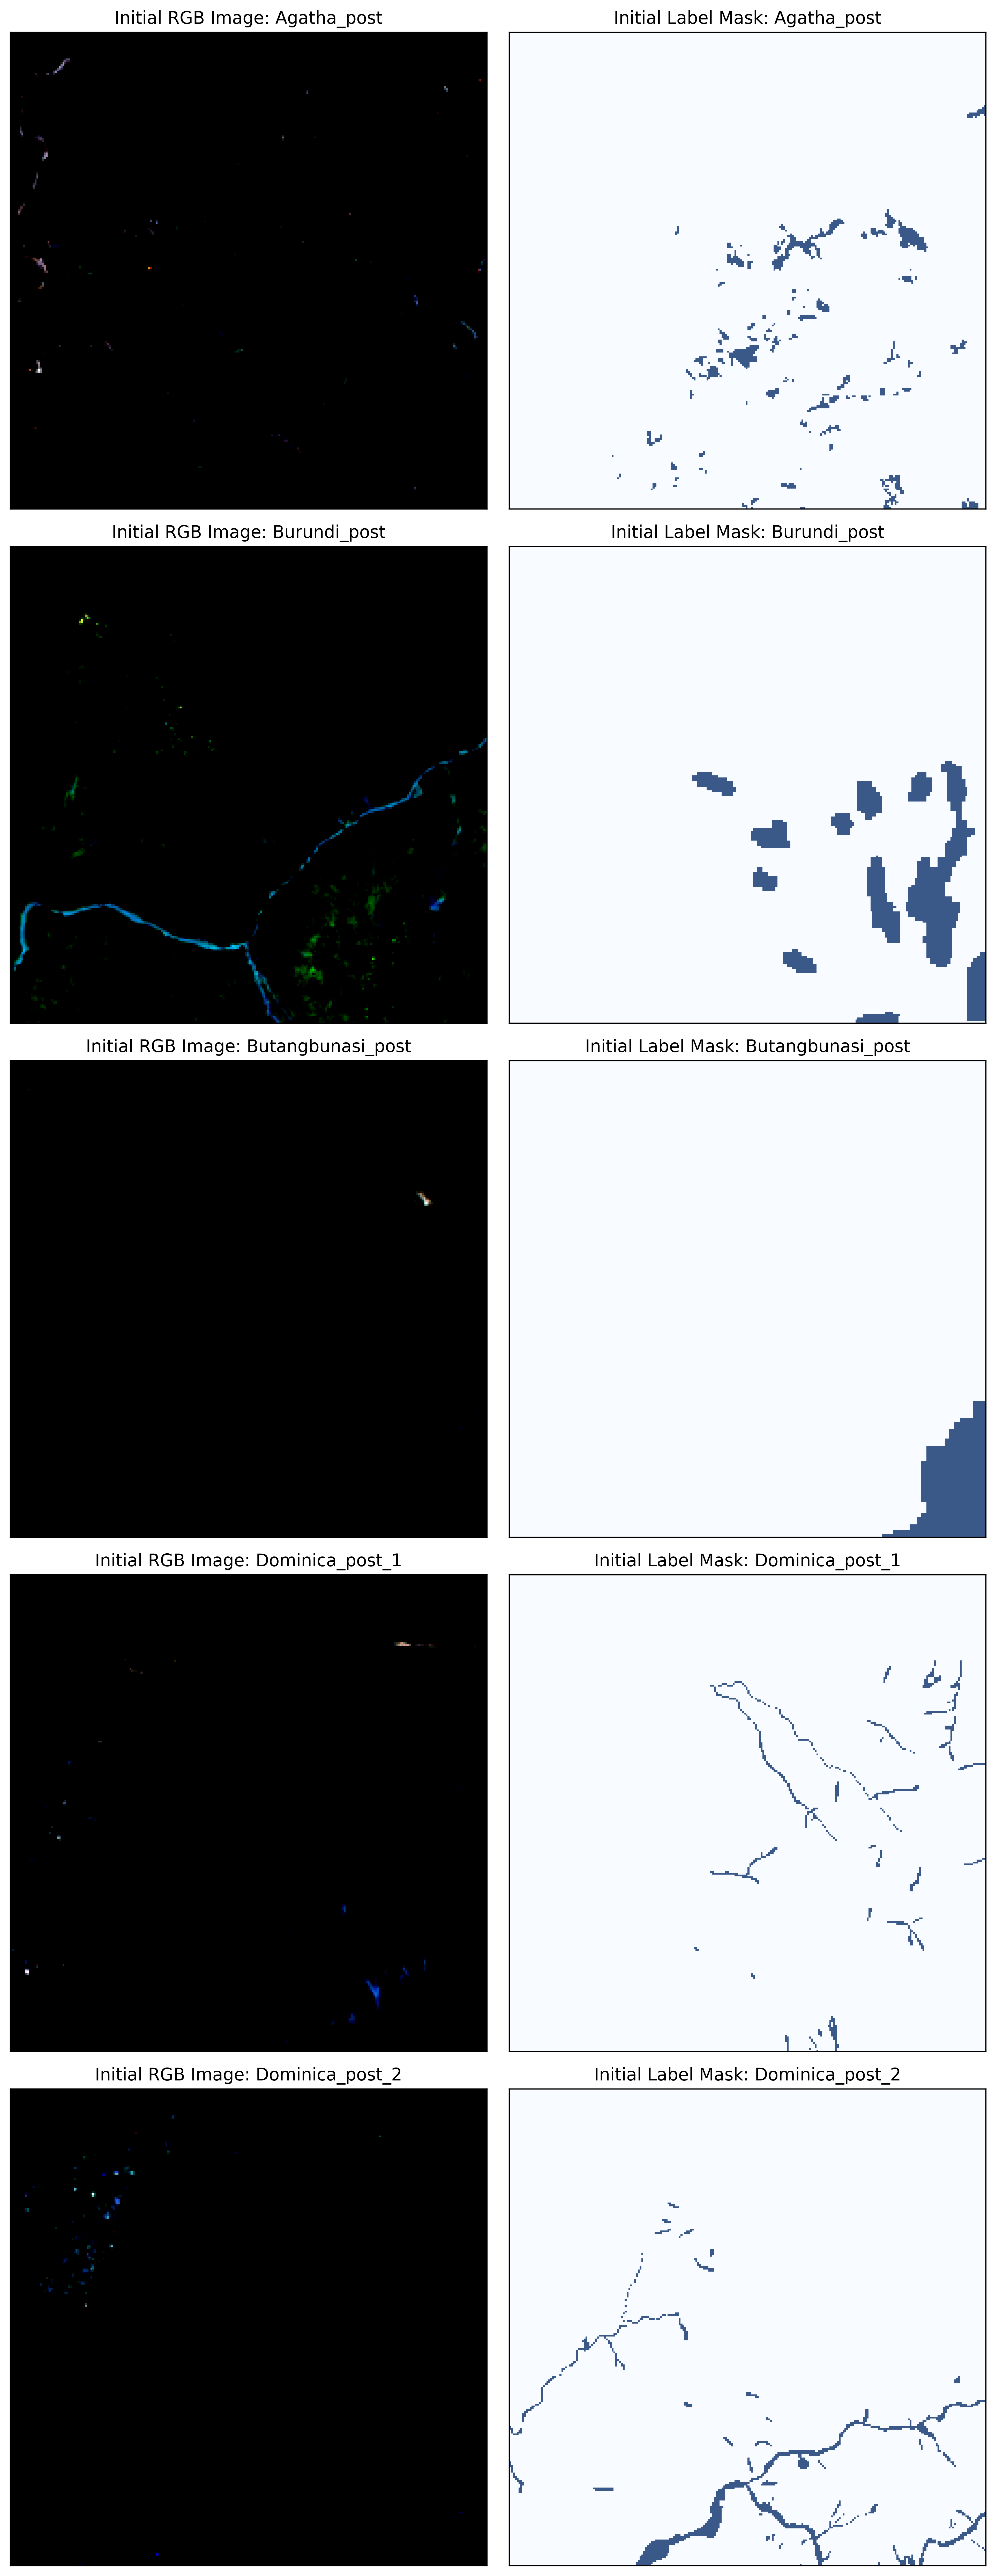

In [ ]:
# Plot the first image patch of five ROIs
roi_names_to_plot = list(filtered_images1.keys())[:5]
roi_names1_to_plot = list(filtered_masks.keys())[:5]

fig, axarr = plt.subplots(len(roi_names_to_plot), 2, figsize=(10, len(roi_names_to_plot) * 5))
for i, (roi_name, roi_name1) in enumerate(zip(roi_names_to_plot, roi_names1_to_plot)):
    workimage_1 = filtered_images1[roi_name]
    workmask = filtered_masks[roi_name1]

    axarr[i, 0].imshow(workimage_1[0][:, :, :3])  # Display the first three channels as RGB
    axarr[i, 0].set_title(f"Initial RGB Image: {roi_name}")
    axarr[i, 0].set(xticks=[], yticks=[])

    axarr[i, 1].imshow(np.squeeze(workmask[0]), cmap='Blues', alpha=0.8)
    axarr[i, 1].set_title(f"Initial Label Mask: {roi_name}")
    axarr[i, 1].set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [33]:
# Function to stack ROIs with the same prefix
def stack_rois_by_prefix(image_dict):
    stacked_data = {}
    for roi_name, roi_array in image_dict.items():
        prefix = roi_name.split('_')[0]  # Extract prefix (e.g., "Dominica" from "Dominica_1")
        if prefix not in stacked_data:
            stacked_data[prefix] = roi_array
        else:
            stacked_data[prefix] = np.concatenate([stacked_data[prefix], roi_array], axis=0)
    return stacked_data

# Function to filter ROIs by sample count
def filter_rois_by_sample_count(image_dict, max_samples=300):
    return {roi_name: roi_array for roi_name, roi_array in image_dict.items() if roi_array.shape[0] < max_samples}

# Stack ROIs with the same prefix
stacked_post_optical_image = stack_rois_by_prefix(filtered_images1)
stacked_pre_optical_image = stack_rois_by_prefix(filtered_images3)
stacked_topographic_image = stack_rois_by_prefix(filtered_images2)
stacked_masks = stack_rois_by_prefix(filtered_masks)
stacked_changemasks = stack_rois_by_prefix(filtered_changemasks)

# Filter ROIs with fewer than 300 images
filtered_optical_image = filter_rois_by_sample_count(stacked_post_optical_image, max_samples=300)
filtered_topographic_image = filter_rois_by_sample_count(stacked_topographic_image, max_samples=300)

# Display results
print("stacked Optical ROIs:")
for key, val in stacked_post_optical_image.items():
    print(f"  {key}: {val.shape}")
print(f"Filtered Optical ROIs: {list(filtered_optical_image.keys())}")
print(f"Filtered Topographic ROIs: {list(filtered_topographic_image.keys())}")


stacked Optical ROIs:
  Agatha: (116, 256, 256, 6)
  Burundi: (38, 256, 256, 6)
  Butangbunasi: (20, 256, 256, 6)
  Dominica: (318, 256, 256, 6)
  Emilia: (302, 256, 256, 6)
  Haiti: (403, 256, 256, 6)
  Honduras: (54, 256, 256, 6)
  India: (26, 256, 256, 6)
  Itogon: (13, 256, 256, 6)
  Japan: (170, 256, 256, 6)
  Kenya: (101, 256, 256, 6)
  Lanao: (6, 256, 256, 6)
  Luding: (273, 256, 256, 6)
  Maerkang: (41, 256, 256, 6)
  Marche: (34, 256, 256, 6)
  Nepal: (48, 256, 256, 6)
  Otis: (29, 256, 256, 6)
  Pacific: (4, 256, 256, 6)
  Palu: (45, 256, 256, 6)
  Papua: (199, 256, 256, 6)
  Rwanda: (22, 256, 256, 6)
  Sanpedro: (76, 256, 256, 6)
  Zeeland: (636, 256, 256, 6)
  Zimbabwe: (77, 256, 256, 6)
Filtered Optical ROIs: ['Agatha', 'Burundi', 'Butangbunasi', 'Honduras', 'India', 'Itogon', 'Japan', 'Kenya', 'Lanao', 'Luding', 'Maerkang', 'Marche', 'Nepal', 'Otis', 'Pacific', 'Palu', 'Papua', 'Rwanda', 'Sanpedro', 'Zimbabwe']
Filtered Topographic ROIs: ['Agatha', 'Burundi', 'Butangbunas

In [34]:
total_patches1 = sum(val.shape[0] for val in stacked_post_optical_image.values())
total_patches2 = sum(val.shape[0] for val in stacked_topographic_image.values())
total_patches3 = sum(val.shape[0] for val in stacked_pre_optical_image.values())
total_patches4 = sum(val.shape[0] for val in stacked_masks.values())

print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)
print("Total patches in image_list3:", total_patches4)

Total patches in image_list1: 3051
Total patches in image_list2: 3051
Total patches in image_list3: 3051
Total patches in image_list3: 3051


In [ ]:
del filtered_images1, filtered_images2, filtered_images3

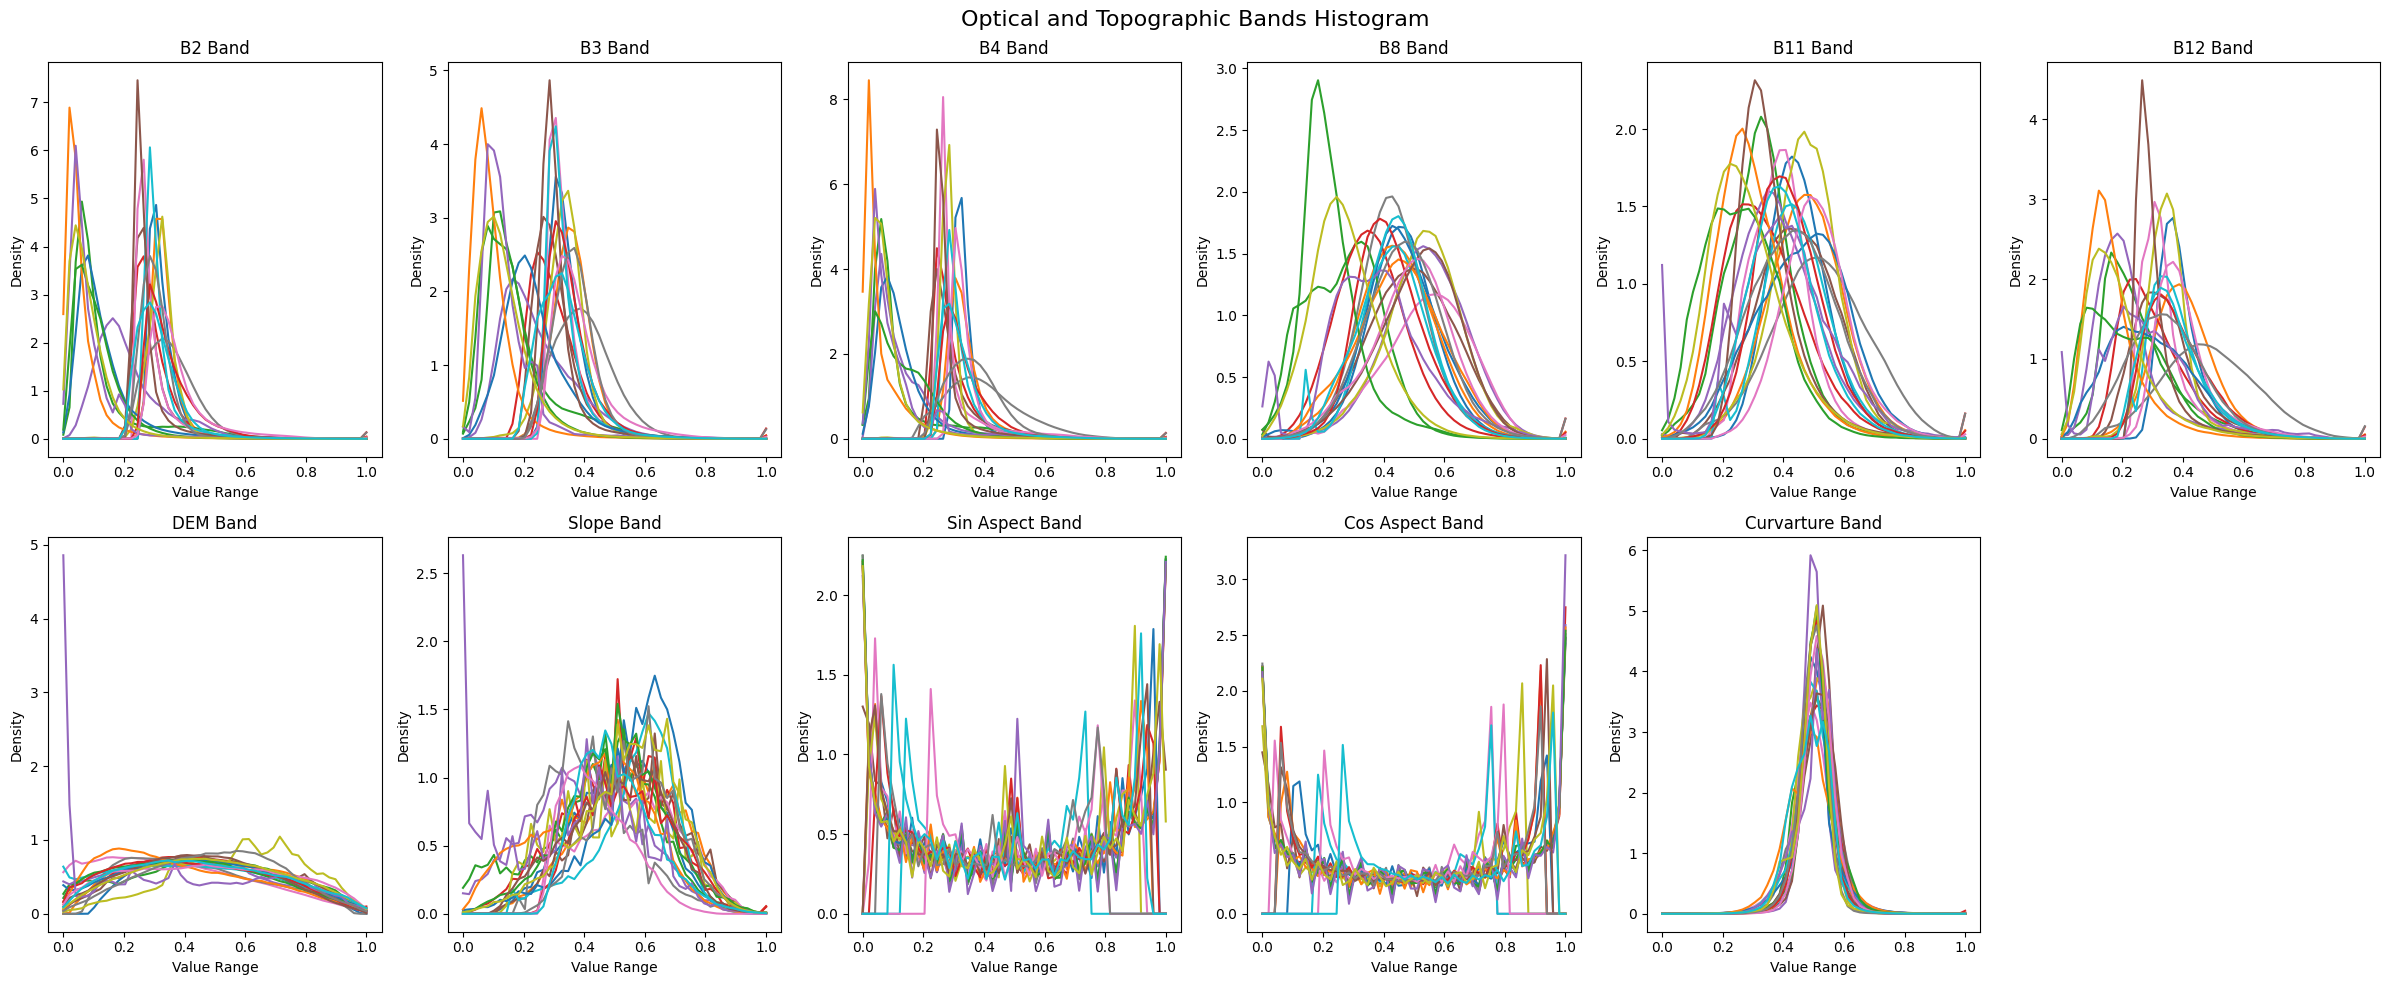

In [ ]:
# Function to compute histograms for each band
def compute_histograms(roi_data, bins=50):
    histograms = {}
    for roi_name, roi_array in roi_data.items():
        bands_hist = []
        for band in range(roi_array.shape[-1]):
            band_data = roi_array[..., band].flatten()
            hist, _ = np.histogram(band_data, bins=bins, density=True)
            bands_hist.append(hist)
        histograms[roi_name] = np.array(bands_hist)
    return histograms

# Compute histograms for filtered optical and topographic data
optical_histograms = compute_histograms(filtered_optical_image)
topographic_histograms = compute_histograms(filtered_topographic_image)

# Function to plot histograms
def plot_histograms(optical_histograms, topographic_histograms, optical_labels, topographic_labels):
    num_optical_bands = len(optical_labels)
    num_topographic_bands = len(topographic_labels)
    rois = list(optical_histograms.keys())
    rois1 = list(topographic_histograms.keys())

    # Define the grid layout: 2 rows and 6 columns
    total_bands = num_optical_bands + num_topographic_bands
    rows = 2
    cols = 6  # Maximum of 6 columns per row
    fig, axes = plt.subplots(rows, cols, figsize=(24, 10))

    # Flatten axes for easy indexing
    axes = axes.flatten()

    # Plot optical bands
    for i in range(num_optical_bands):
        ax = axes[i]
        for roi_name in rois:
            x = np.linspace(0, 1, optical_histograms[roi_name][i].shape[0])
            ax.plot(x, optical_histograms[roi_name][i], label=roi_name)
        ax.set_title(f"{optical_labels[i]} Band")
        ax.set_xlabel("Value Range")
        ax.set_ylabel("Density")
        #ax.legend(loc="upper right", fontsize=8)

    # Plot topographic bands
    for i in range(num_topographic_bands):
        ax = axes[num_optical_bands + i]
        for roi_name in rois1:
            x = np.linspace(0, 1, topographic_histograms[roi_name][i].shape[0])
            ax.plot(x, topographic_histograms[roi_name][i], label=roi_name)
        ax.set_title(f"{topographic_labels[i]} Band")
        ax.set_xlabel("Value Range")
        ax.set_ylabel("Density")
        #ax.legend(loc="upper right", fontsize=8)

    # Turn off any unused subplots
    for j in range(total_bands, rows * cols):
        axes[j].axis("off")
    # Add legend to the last plot of topographic bands
    #ax.legend(loc='best', bbox_to_anchor=(1.15, 1), title="ROIs")
    # Add a global title and adjust layout
    plt.suptitle("Optical and Topographic Bands Histogram", fontsize=16)
    plt.tight_layout()  # Adjust layout to fit the title
    plt.show()

# Band labels
optical_band_labels = ["B2", "B3", "B4", "B8", "B11", "B12"]
topographic_band_labels = ["DEM", "Slope", "Sin Aspect", "Cos Aspect", "Curvarture"]

# Plot the histograms
plot_histograms(
    optical_histograms,
    topographic_histograms,
    optical_band_labels,
    topographic_band_labels
)

In [35]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

(20, 300)


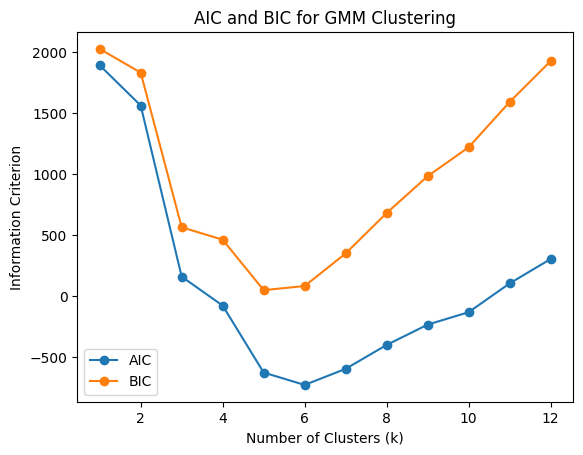

In [ ]:
# Flatten histograms into feature vectors
features1 = []
roi_names = []
for roi_name, histograms in optical_histograms.items():
    roi_names.append(roi_name)
    features1.append(histograms.flatten())  # Flatten into a single vector
features1 = np.array(features1)

features2 = []
roi_names = []
for roi_name, histograms in topographic_histograms.items():
    roi_names.append(roi_name)
    features2.append(histograms.flatten())  # Flatten into a single vector
features2 = np.array(features2)

features = np.add(0.5*features1, 0.5*features2)
print(features.shape)

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Dimensionality reduction with PCA (optional)
pca = PCA(n_components=15)  # Reduce to 10 dimensions
features_pca = pca.fit_transform(features_scaled)

# Find optimum number of clusters using AIC or BIC
aics = [] # Akaike Information Criterion
bics = [] # Bayesian Information Criterion
for k in range(1, 13):
    gmm = GaussianMixture(n_components=k, random_state=42) # Re-initialize GMM for each k
    gmm.fit(features_pca)
    aics.append(gmm.aic(features_pca))
    bics.append(gmm.bic(features_pca))

# Plot AIC and BIC values to find the elbow point
plt.plot(range(1, 13), aics, marker='o', label='AIC')
plt.plot(range(1, 13), bics, marker='o', label='BIC')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Information Criterion')
plt.title('AIC and BIC for GMM Clustering')
plt.legend()
plt.show()

In [ ]:
# Clustering with GMM
gmm = GaussianMixture(n_components=5, random_state=42)
cluster_labels = gmm.fit_predict(features_pca)

# Map each ROI to its cluster
roi_clusters = {roi_names[i]: cluster_labels[i] for i in range(len(roi_names))}

# Group ROIs by cluster
from collections import defaultdict
cluster_groups = defaultdict(list)
for roi, cluster in roi_clusters.items():
    cluster_groups[cluster].append(roi)

# Display ROIs for each cluster
for cluster_id, rois in cluster_groups.items():
    print(f"Cluster {cluster_id}: {', '.join(rois)}")

Cluster 2: Agatha, Luding, Palu, Papua
Cluster 4: Burundi, Honduras, Itogon, Japan, Lanao, Otis, Rwanda, Zimbabwe
Cluster 1: Butangbunasi, Maerkang, Nepal, San
Cluster 3: India, Marche, Pacific
Cluster 0: Kenya


In [ ]:
labels_1 = [
    2, 2, 1, 4, 3, 4, 4, 0, 2, 2, 1, 3, 1, 2, 3, 4, 2, 2, 1, 2
]

In [ ]:
labels_2 = [
    3, 0, 2, 3, 1, 4, 2, 0, 4, 2, 2, 3, 1, 3, 3, 4, 4, 0, 3, 0
]

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Assuming `X` is your histogram feature matrix (shape: 20x300)

# Compute Silhouette Scores
silhouette_1 = silhouette_score(features, labels_1)
silhouette_2 = silhouette_score(features, labels_2)

# Compute Davies-Bouldin Index
dbi_1 = davies_bouldin_score(features, labels_1)
dbi_2 = davies_bouldin_score(features, labels_2)

# Compute Adjusted Rand Index (to compare the two clustering results)
ari = adjusted_rand_score(labels_1, labels_2)

# Print Results
print(f"Silhouette Score for Clustering 1: {silhouette_1}")
print(f"Silhouette Score for Clustering 2: {silhouette_2}")
print(f"Davies-Bouldin Index for Clustering 1: {dbi_1}")
print(f"Davies-Bouldin Index for Clustering 2: {dbi_2}")
print(f"Adjusted Rand Index between Clustering 1 and Clustering 2: {ari}")


Silhouette Score for Clustering 1: 0.06146071731355882
Silhouette Score for Clustering 2: -0.14139328179347166
Davies-Bouldin Index for Clustering 1: 1.4636815714290408
Davies-Bouldin Index for Clustering 2: 2.8538364191051486
Adjusted Rand Index between Clustering 1 and Clustering 2: 0.009909448146249786


In [ ]:
del filtered_optical_image, filtered_topographic_image

In [40]:
# Define groups with ROI names
roi_groups = {
    "Group 0": ["Agatha", "Burundi", "Lanao", "Luding", "Otis", "Papua", "Rwanda"],
    "Group 2": ["Butangbunasi", "Maerkang", "Sanpedro"],
    "Group 3": ["Honduras", "Itogon", "Japan", "Palu"],
    "Group 4": ["India", "Pacific", "Nepal"],
    "Group 5": ["Kenya", "Zimbabwe"],
    "Group 6": ["Dominica"],
    "Group 7": ["Emilia", "Marche"],
    "Group 8": ["Haiti"],
    "Group 9": ["Zeeland"]
}

# Function to get grouped ROIs
def get_grouped_rois(image_dict, groups):
    grouped_data = {}
    for group_name, roi_names in groups.items():
        group_arrays = [image_dict[roi_name] for roi_name in roi_names if roi_name in image_dict]
        if group_arrays:  # Check if there are valid ROIs in this group
            grouped_data[group_name] = np.concatenate(group_arrays, axis=0)
    return grouped_data

In [41]:
# Get grouped ROIs for optical and topographic data
grouped_post_optical = get_grouped_rois(stacked_post_optical_image, roi_groups)
grouped_pre_optical = get_grouped_rois(stacked_pre_optical_image, roi_groups)
grouped_masks = get_grouped_rois(stacked_masks, roi_groups)
grouped_changemasks = get_grouped_rois(stacked_changemasks, roi_groups)

In [42]:
grouped_topographic = get_grouped_rois(stacked_topographic_image, roi_groups)
# Display results
print(f"Optical Group Histograms: {list(grouped_post_optical.keys())}")
print(f"Topographic Group Histograms: {list(grouped_topographic.keys())}")
print("stacked Optical ROIs:")
for key, val in grouped_post_optical.items():
    print(f"  {key}: {val.shape}")

for key, val in grouped_masks.items():
    print(f"  {key}: {val.shape}")

Optical Group Histograms: ['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9']
Topographic Group Histograms: ['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9']
stacked Optical ROIs:
  Group 0: (683, 256, 256, 6)
  Group 2: (137, 256, 256, 6)
  Group 3: (282, 256, 256, 6)
  Group 4: (78, 256, 256, 6)
  Group 5: (178, 256, 256, 6)
  Group 6: (318, 256, 256, 6)
  Group 7: (336, 256, 256, 6)
  Group 8: (403, 256, 256, 6)
  Group 9: (636, 256, 256, 6)
  Group 0: (683, 256, 256, 1)
  Group 2: (137, 256, 256, 1)
  Group 3: (282, 256, 256, 1)
  Group 4: (78, 256, 256, 1)
  Group 5: (178, 256, 256, 1)
  Group 6: (318, 256, 256, 1)
  Group 7: (336, 256, 256, 1)
  Group 8: (403, 256, 256, 1)
  Group 9: (636, 256, 256, 1)


In [43]:
total_patches1 = sum(val.shape[0] for val in grouped_post_optical.values())
total_patches2 = sum(val.shape[0] for val in grouped_topographic.values())
total_patches3 = sum(val.shape[0] for val in grouped_pre_optical.values())
total_patches4 = sum(val.shape[0] for val in grouped_masks.values())


print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)
print("Total patches in image_list3:", total_patches4)

Total patches in image_list1: 3051
Total patches in image_list2: 3051
Total patches in image_list3: 3051
Total patches in image_list3: 3051


In [ ]:
del stacked_post_optical_image, stacked_pre_optical_image, stacked_topographic_image

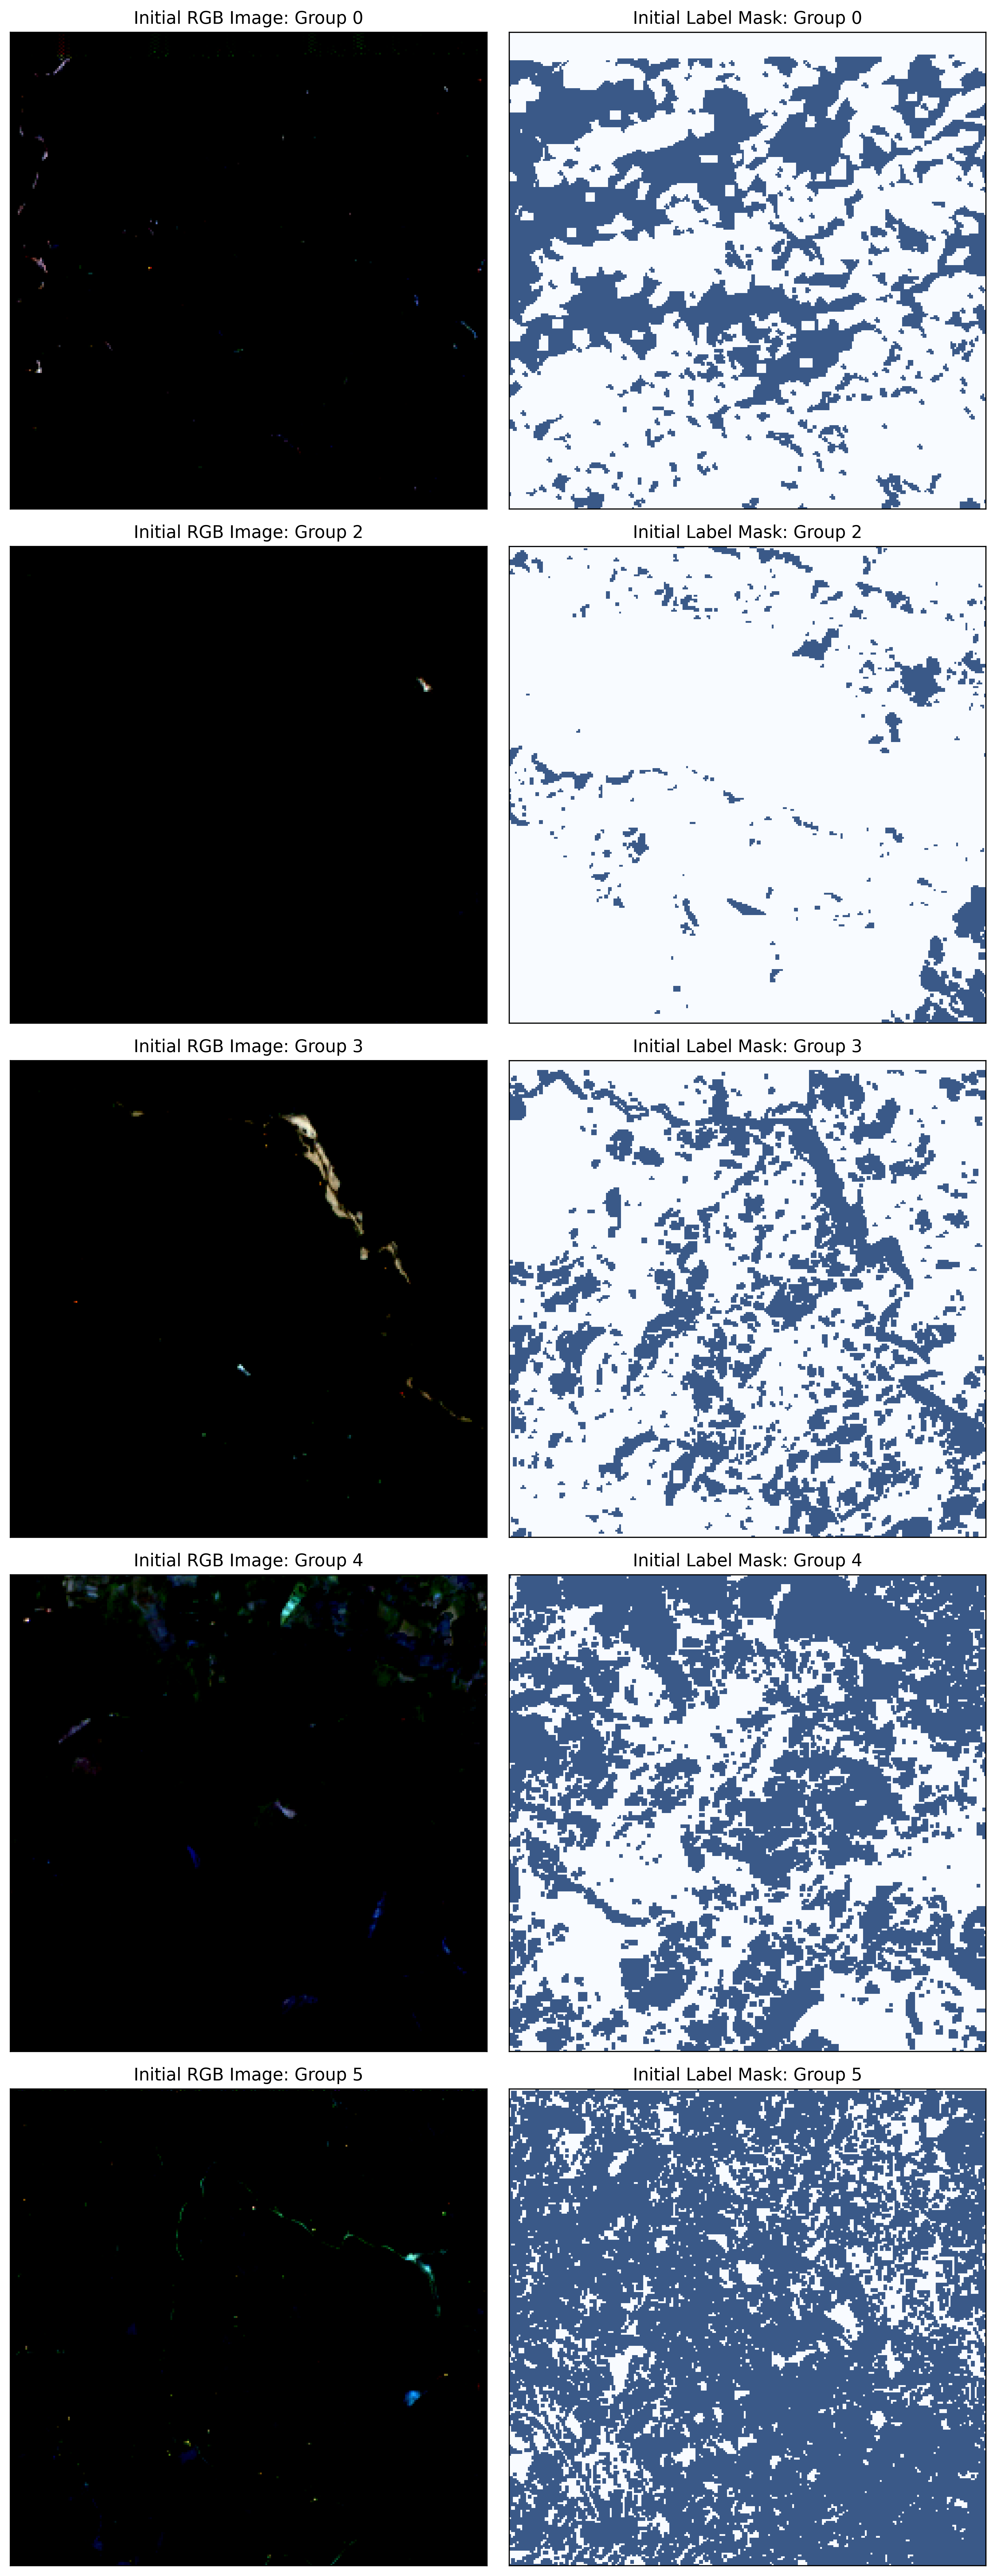

In [64]:
# Plot the first image patch of five ROIs
roi_names_to_plot = list(grouped_post_optical.keys())[:5]
roi_names1_to_plot = list(grouped_changemasks.keys())[:5]

fig, axarr = plt.subplots(len(roi_names_to_plot), 2, figsize=(10, len(roi_names_to_plot) * 5))
for i, (roi_name, roi_name1) in enumerate(zip(roi_names_to_plot, roi_names1_to_plot)):
    workimage_1 = grouped_post_optical[roi_name]
    workmask = grouped_changemasks[roi_name1]

    axarr[i, 0].imshow(workimage_1[0][:, :, :3])  # Display the first three channels as RGB
    axarr[i, 0].set_title(f"Initial RGB Image: {roi_name}")
    axarr[i, 0].set(xticks=[], yticks=[])

    axarr[i, 1].imshow(np.squeeze(workmask[0]), cmap='Blues', alpha=0.8)
    axarr[i, 1].set_title(f"Initial Label Mask: {roi_name}")
    axarr[i, 1].set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [46]:
import pickle

# Define file paths
output_path = "/content/Dictionnary/"  # Replace with your desired directory
grouped_post_optical_file = output_path + "grouped_post_optical.pkl"
grouped_pre_optical_file = output_path + "grouped_pre_optical.pkl"
grouped_topographic_file = output_path + "grouped_topographic.pkl"
grouped_masks_file = output_path + "grouped_masks.pkl"
grouped_changemasks_file = output_path + "grouped_changemasks.pkl"


# Save the dictionaries
with open(grouped_post_optical_file, "wb") as f:
    pickle.dump(grouped_post_optical, f)

with open(grouped_pre_optical_file, "wb") as f:
    pickle.dump(grouped_pre_optical, f)

with open(grouped_topographic_file, "wb") as f:
    pickle.dump(grouped_topographic, f)

with open(grouped_masks_file, "wb") as f:
    pickle.dump(grouped_masks, f)

with open(grouped_changemasks_file, "wb") as f:
    pickle.dump(grouped_changemasks, f)
print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [58]:
import pickle

# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_post_optical_file = output_path + "grouped_post_optical.pkl"

# Save the dictionaries
with open(grouped_post_optical_file, "wb") as f:
    pickle.dump(grouped_post_optical, f)

print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [63]:

# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_pre_optical_file = output_path + "grouped_pre_optical.pkl"

with open(grouped_pre_optical_file, "wb") as f:
    pickle.dump(grouped_pre_optical, f)

print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [60]:

# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_topographic_file = output_path + "grouped_topographic.pkl"

with open(grouped_topographic_file, "wb") as f:
    pickle.dump(grouped_topographic, f)

print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [61]:
# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_masks_file = output_path + "grouped_masks.pkl"

with open(grouped_masks_file, "wb") as f:
    pickle.dump(grouped_masks, f)
print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [62]:
# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_changemasks_file = output_path + "grouped_changemasks.pkl"

with open(grouped_changemasks_file, "wb") as f:
    pickle.dump(grouped_changemasks, f)
print("Dictionaries saved successfully!")

Dictionaries saved successfully!
